## Figures 5, 6, 7, 8, 9 — Stationary modes, energy spectra, and photon analogy

This notebook reproduces **Figures 5, 6, 7, 8, and 9** of the paper.

Using precomputed high-resolution Floquet mode data (`Mode_mid_ppp300.npy`,
`Mode_big_ppp300_groundstate_testreal.npy`,
`Mode_big_ppp300_excitedstate_10modes_QHO_testreal.npy`),
it demonstrates:
- Discrete eigenfrequency sequences in finite QHO boxes (Figs 5, 6)
- The superposition/modular-design principle for concatenated media (Fig 6)
- The classical photon-energy analogy: ground state and excited state of the EM field (Figs 7–9)


In [5]:
import numpy as np
import itertools
import scipy.special as sp
from scipy.sparse import diags
from scipy.optimize import fsolve
from scipy.sparse.linalg import eigs
from scipy.linalg import eigh
from scipy.special import mathieu_a, mathieu_cem, mathieu_b, mathieu_sem
from scipy.integrate import odeint
from scipy.integrate import solve_ivp
from scipy.stats import linregress
from numpy import linalg as LA
import scipy.linalg
import cmath as cm
import matplotlib.pyplot as plt

### QHO medium setup — $F(x)$ profile

Defines the piecewise-parabolic $F(x)$ and its physical form,
and plots one period as a reference. Produces `Modulation_negative_HQO.png`.


1 3


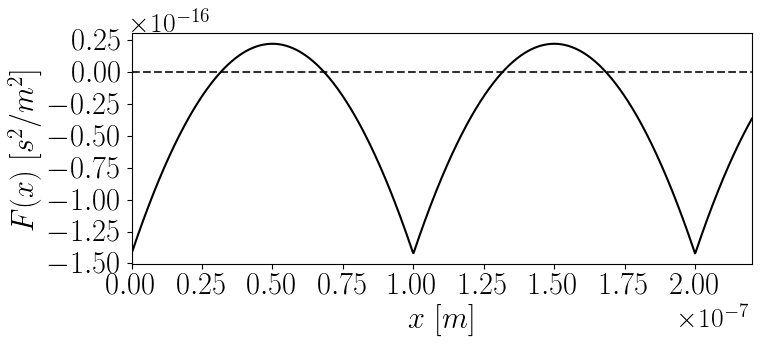

In [6]:
# Define the base function over [0, pi]
def f_base(x, ala, qlq):
    return (ala+2*qlq-4*qlq*(x-np.pi/2)**2)

def f_base_physical(x, C0, C1, lamb):
    return (C0+C1)-2*C1*(np.pi/lamb)**2*(x-lamb/2)**2


qtest = 20
pent = 3
nlist = np.linspace(0,3,4)
energiesana = (0.5+nlist)*4*np.sqrt(qtest)

#ymax = 1.05*np.max(np.pi*np.sqrt(aap)/np.sqrt(np.abs(s0))/lamb)
eps0 = 8.854e-12
mu0 = 1.25663706127e-6
lamb = 100e-9
kmax = 2e8
vv = 299792458
#vv = vv + 15700000


alph2 = 1
bet2 = pent*alph2
s0 = -alph2*eps0*mu0

C0 = -1/vv**2
C1 = -3*C0

print(alph2,bet2)

xshift = lamb
xplot = np.array(np.linspace(-lamb*2,lamb*2,2000))+xshift
yplot = f_base_physical(xplot %lamb,C0,C1,lamb)


fonty = 22
fig1 = plt.figure(1, figsize=(8, 3))
plt.rc('text', usetex=True)

plt.plot(xplot,yplot,'k-')
#plt.axvline(x=xshift, color='r', linestyle='--', alpha=0.8)
#plt.axvline(x=lamb+xshift, color='r', linestyle='--', alpha=0.8)
plt.axhline(y=0, color='k', linestyle='--', alpha=0.8)

# Set font size for the offset text
ax = plt.gca()
ax.xaxis.get_offset_text().set_fontsize(fonty-2)
ax.yaxis.get_offset_text().set_fontsize(fonty-2)

plt.xlabel(r'$x$ $[m]$',fontsize=fonty)
plt.ylabel(r'$F(x)$ $[s^2/m^2]$',fontsize=fonty)
plt.xticks(size=fonty)
plt.yticks(size=fonty)
#plt.xlim(-lamb/5+xshift, lamb+lamb/5+xshift)   # set the ylim to ymin, ymax
plt.xlim(0, 2*lamb+lamb/5)   # set the ylim to ymin, ymax
#plt.xlim(0.,40)   # set the ylim to ymin, ymax
#plt.ylim(-0.4e-9, 2e-11)   # set the ylim to ymin, ymax
#plt.grid()
plt.yscale('linear')
fig1 = plt.gcf()
plt.show()

fig1.savefig('Modulation_negative_HQO.png', format='png', dpi=1000, bbox_inches='tight')

### → Figure 5a — One-wavelength box ($L = \lambda$, $P = 1$)

Solves the eigenvalue problem for a QHO box of length $L = \lambda$
and plots stationary mode shapes and the eigenfrequency ladder.
Produces `Modesfinite_quantum_onewavelength.png` and `Evol_disp_HQO_1wavelength_inabox.png`.


In [7]:
"""
Indefinite‑weight slab  (ε sign‑changing)
----------------------------------------

Solves  −Φ'' = omega² F(x) Φ   with F(x) that takes BOTH signs.
Dirichlet at x=0 and x=L=m·λ.

Algorithm:
  * build stiffness T and mass M (diagonal, sign‑changing);
  * solve   (M⁻¹ T) Φ = λ Φ   with NumPy's dense eig;
  * keep real, positive eigen‑values   omeg0 = √λ;
  * group into m‑sized “bands’’;
  * verify indefinite orthogonality   ∫ F Φ_m Φ_n dx = 0 for m≠n
    (diagonal entries may be ±1).

Only NumPy + Matplotlib used.
"""

import numpy as np
import matplotlib.pyplot as plt
from numpy.linalg import eig, inv

# --- Define the profile directly on [0, λ] ---
def f_base_physical(x, C0, C1, lamb):
    return (C0 + C1) - 2 * C1 * (np.pi / lamb)**2 * (x - lamb / 2)**2


def slab_indefinite(C0, C1, lam, m, ppp, n_bands):
    L   = m*lam
    Nx  = 4*ppp + 1
    #Nx  = m*ppp + 1
    x   = np.linspace(0.0, L, Nx)
    dx  = x[1] - x[0]

    # permittivity profile (sign‑changing)
    FFF = f_base_physical(x % lam, C0, C1, lam)
    #FFF = C0 + C1*np.cos(2*np.pi*x/lam)
    if np.all(FFF > 0) or np.all(FFF < 0):
        raise ValueError("Choose C1 so that F(x) changes sign.")

    # stiffness matrix T (Dirichlet interior)
    Nint = Nx - 2
    main =  2.0*np.ones(Nint)/dx**2
    off  = -1.0*np.ones(Nint-1)/dx**2
    T    = np.diag(main) + np.diag(off,1) + np.diag(off,-1)

    # mass matrix M  (diagonal, possibly negative)
    M    = np.diag(FFF[1:-1])
    A    = inv(M) @ T                       # standard but NOT symmetric

    # ----- dense eigen‑solve (general complex) ------------------------
    lam_vals, vec = eig(A)                 # λ may come out complex
    # keep only eigen‑values with tiny imaginary part and λ>0
    tol_im = 1e-10
    #mask   = (np.abs(lam_vals.imag) < tol_im) & (lam_vals.real > 0)
    #lam_r  = lam_vals.real[mask]
    #vec_r  = vec[:, mask]
    lam_r  = lam_vals.real
    vec_r  = vec

    # sort by increasing k0
    idx    = np.argsort(np.sqrt(lam_r))
    lam_r  = lam_r[idx]
    vec_r  = vec_r[:, idx]

    need   = n_bands * m
    lam_r, vec_r = lam_r[:need], vec_r[:, :need]

    # build full Φ with boundary zeros
    Phi = np.zeros((Nx, need))
    Phi[1:-1, :] = vec_r

    # normalise in the indefinite inner product  <f,f>ε = ±1
    sign_diag = np.trapz(FFF[:,None]*Phi**2, x, axis=0)
    Phi /= np.sqrt(np.abs(sign_diag))       # gives ±1 norms
    
# --- NEW: ε‑weighted Gram–Schmidt to clean up near‑degenerate modes ---
    for j in range(Phi.shape[1]):
        v = Phi[:, j]
        for k in range(j):                                  # subtract proj
            v -= np.trapz(FFF * Phi[:, k] * v, x) * Phi[:, k]
        v /= np.sqrt(np.abs(np.trapz(FFF * v * v, x)))      # renormalise
        Phi[:, j] = v
    
    omeg0  = np.sqrt(lam_r)
    bands = [slice(i*m, (i+1)*m) for i in range(n_bands)]
    
    S = np.trapz(FFF[:,None,None]*Phi[:,:,None]*Phi[:,None,:], x, axis=0)
    print("max |S_nn−1| =", np.max(np.abs(np.diag(S)-1)))
    print("max |S_nm| (n≠m) =", np.max(np.abs(S-np.diag(np.diag(S)))))    
    
    # ---------------- split into consecutive blocks of length m --------
    o0_bands  = [omeg0[i*m:(i+1)*m]        for i in range(n_bands)]
    Phi_bands = [Phi[:, i*m:(i+1)*m]    for i in range(n_bands)]
    
    
    return x, FFF, o0_bands, Phi_bands, bands, sign_diag


In [8]:
from matplotlib.ticker import ScalarFormatter

# ---------------- parameters ------------------------------------------
eps0 = 8.854e-12
mu0 = 1.25663706127e-6
lam        = 100e-9            # period
m          = 1              # periods  -> m modes per band
n_bands    = 4              # how many bands to keep
ppp        = 300            # grid density
C0       =  -eps0*mu0          # background -1.5 was the first value
#C0 = eps0*mu0
#C0 = -2.2252529080969186e-18
#C1       = np.abs(C0)*1.4           # modulation (gives ε min ≈ -1.5 < 0)
C1 = eps0*mu0*1.4
# ----------------------------------------------------------------------

# ---------------- run --------------------------------------------------
x, FFF, o0_bands, Phi_bands, bands, sig = slab_indefinite(
        C0, C1, lam, m, ppp, n_bands)

#print(np.concatenate(o0_bands))

print(o0_bands)

omegana0 = 0.5*2*np.pi*np.sqrt(2*C1)/((C0+C1)*lam)
omegana1 = 1.5*2*np.pi*np.sqrt(2*C1)/((C0+C1)*lam)
omegana2 = 2.5*2*np.pi*np.sqrt(2*C1)/((C0+C1)*lam)
omegana3 = 3.5*2*np.pi*np.sqrt(2*C1)/((C0+C1)*lam)
omegana4 = 4.5*2*np.pi*np.sqrt(2*C1)/((C0+C1)*lam)
omegana5 = 5.5*2*np.pi*np.sqrt(2*C1)/((C0+C1)*lam)
print(omegana0,omegana1,omegana2,omegana3,omegana4,omegana5)

qq0 = C1*omegana0**2*lam**2/(2*np.pi**2)
print(2*qq0)

# ---- print nice summary ------------------------------------------
print(f"Periodic slab: C0 = {C0},  C1 = {C1},  λ = {lam}")
for b, olist in enumerate(o0_bands, start=1):
    txt = ", ".join(f"{oo:.5f}" for oo in olist)
    print(f"Pass‑band {b:>2d}:  o0 = [{txt}]")

# --- Plot first N modes along with F(x) on a twin y-axis
N = 4  # Number of modes to plot
#FFF = f_base_physical(x % lam, C0, C1, lam)

# ---------- You already have ε-normalized eigenmodes ----------
Phi_eps = np.hstack(Phi_bands)          # (Nx, K)  columns are eigenmodes
omega   = np.concatenate(o0_bands)      # (K,)
Nx, K   = Phi_eps.shape

# ---------- Make an L2-rescaled copy (per column only) ----------
# Use simple trapz for L2; (optionally) trapezoid weights W if you prefer.
l2 = np.sqrt(np.trapz(Phi_eps**2, x, axis=0))   # shape (K,)
Phi_L2 = Phi_eps / l2                           # still exact eigenvectors


# (Sanity) M-orthogonality off-diagonals stay ~0; diagonals are not ±1 anymore
Mmat    = np.diag(FFF[1:-1])
Phi_int = Phi_L2[1:-1, :]
S = Phi_int.T @ (Mmat @ Phi_int)                # Φᵀ M Φ   (K,K)
# Build T on interior exactly as in your solver
dx   = x[1] - x[0]
Nint = Phi_int.shape[0]
main =  2.0*np.ones(Nint)/dx**2
off  = -1.0*np.ones(Nint-1)/dx**2
Tmat = np.diag(main) + np.diag(off,1) + np.diag(off,-1)
Kmat = Phi_int.T @ (Tmat  @ Phi_int)            # Φᵀ T Φ   (K,K)

# (Optional) verify eigen relation still holds (it does; scaling doesn’t change it)
res = Tmat @ Phi_int - Mmat @ (Phi_int * (omega**2))
rel_inf = np.linalg.norm(res, np.inf) / (np.linalg.norm(Tmat @ Phi_int, np.inf) + 1e-300)
print("eig residual (rel inf) after L2 rescale =", f"{rel_inf:.3e}")



# ---------- Choose initial modal amplitudes using L2 interpretation ----------
# --- Choose initial modal amplitudes q(0)
u0 = 1*(Phi_eps[:, 0]/omega[0]+Phi_eps[:, 1]/omega[1]+Phi_eps[:, 2]/omega[2] + Phi_eps[:, 3]/omega[3])
#u0 = 1*(Phi_eps[:, 0]/omega[0]+ Phi_eps[:, 3]/omega[3])
q_eps = np.trapz(FFF[:, None] * u0[:, None] * Phi_eps, x, axis=0)
print(q_eps)
qL2 = q_eps * l2                               # D^{-1} q_eps
print(qL2)

# Field consistency check
u_from_eps = Phi_eps @ q_eps
u_from_L2  = Phi_L2  @ (l2 * q_eps)    # must match u_from_eps
print("||u_eps - u_L2|| / ||u_eps|| =",
      np.linalg.norm(u_from_eps - u_from_L2) / (np.linalg.norm(u_from_eps) + 1e-300))


# Example: equal-energy-by-displacement: q_n(0) = 1/ω_n (you can choose any rule)
q0  = np.zeros(K)
pick = [0,1,2, 3] # modes you want
q0[pick] = 2.0 / omega[pick]
print(q0)
dq0 = np.zeros_like(q0)

# ---------- Reconstruct fields and compute energy (normalization-agnostic) ----------
# Time evolution (decoupled cosines) is valid since columns are still eigenvectors
Tfinal = 2*np.pi/omegana3
Nt = 1000
t  = np.linspace(0.0, Tfinal, Nt)
q  = q0 * np.cos(np.outer(t, omega))            # (Nt,K)
dq = -q0 * omega * np.sin(np.outer(t, omega))   # (Nt,K)
qL2  = qL2 * np.cos(np.outer(t, omega))            # (Nt,K)
dqL2 = -qL2 * omega * np.sin(np.outer(t, omega))   # (Nt,K)

# Energy via general modal form (works for ANY normalization)
E_modal = 0.5 * (np.einsum('ti,ij,tj->t', dq, S, dq) +
                 np.einsum('ti,ij,tj->t',  q, Kmat, q))

# (Cross-check) energy via physical-space quadratic form
u  = q @ Phi_eps.T                                      # (Nt, Nx)
ut = dq @ Phi_eps.T                                     # (Nt, Nx)
uL2  = qL2 @ Phi_L2.T                                      # (Nt, Nx)
utL2 = dqL2 @ Phi_L2.T                                     # (Nt, Nx)
u_int  = q  @ Phi_int.T
ut_int = dq @ Phi_int.T
E_quad = 0.5 * (np.einsum('ti,ij,tj->t', ut_int, Mmat, ut_int) +
                np.einsum('ti,ij,tj->t',  u_int,  Tmat,  u_int))


E0 = E_quad[0]
print(f"[Energy check] max|E_modal - E_quad| / E0 = {np.max(np.abs(E_modal - E_quad))/E0:.3e}")
print(f"[Energy check] rel variation of E_quad   = {np.ptp(E_quad)/E0:.3e}")

# ---------- Per-mode energy at t=0 (with dq0=0) ----------
# For exact eigenvectors: Kmat ≈ S @ diag(ω^2), so E_n(0) ≈ 0.5 * S_nn * (1)
E_modes_0 = 0.5 * (q0**2) * np.diag(Kmat)
print("E per selected mode at t=0:", E_modes_0[pick])
print("S_nn for selected modes   :", np.diag(S)[pick])



/var/folders/xc/bmsk3vw13cg973pbrrv1dh6c0000gn/T/ipykernel_29253/2584905266.py:62: RuntimeWarning: invalid value encountered in sqrt
  idx    = np.argsort(np.sqrt(lam_r))


max |S_nn−1| = 6.661338147750939e-16
max |S_nm| (n≠m) = 3.1030617169204393e-16
[array([3.93997103e+16]), array([1.18197679e+17]), array([1.96991406e+17]), array([2.75778045e+17])]
3.939981714217616e+16 1.181994514265285e+17 1.9699908571088083e+17 2.7579871999523318e+17 3.545983542795855e+17 4.333979885639378e+17
24.500000000000007
Periodic slab: C0 = -1.1126264540484579e-17,  C1 = 1.557677035667841e-17,  λ = 1e-07
Pass‑band  1:  o0 = [39399710300109768.00000]
Pass‑band  2:  o0 = [118197679273563824.00000]
Pass‑band  3:  o0 = [196991406378287648.00000]
Pass‑band  4:  o0 = [275778044868194272.00000]
eig residual (rel inf) after L2 rescale = 1.655e-09
[2.53808973e-17 8.46040300e-18 5.07636358e-18 3.62610447e-18]
[1.70143589e-08 5.67150222e-09 3.40294214e-09 2.43071669e-09]
||u_eps - u_L2|| / ||u_eps|| = 1.143823059882193e-16
[5.07617946e-17 1.69208060e-17 1.01527272e-17 7.25220893e-18]
[Energy check] max|E_modal - E_quad| / E0 = 1.745e-13
[Energy check] rel variation of E_quad   = 2.672e-

/Users/Arnaud/anaconda3/lib/python3.11/site-packages/matplotlib/cbook/__init__.py:1340: ComplexWarning: Casting complex values to real discards the imaginary part
  return np.asarray(x, float)


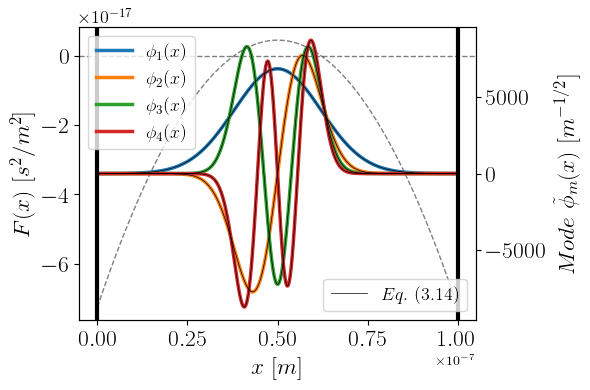

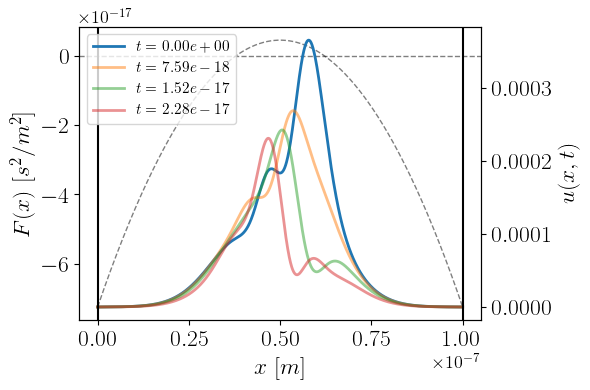

2.1363158258750545e-07


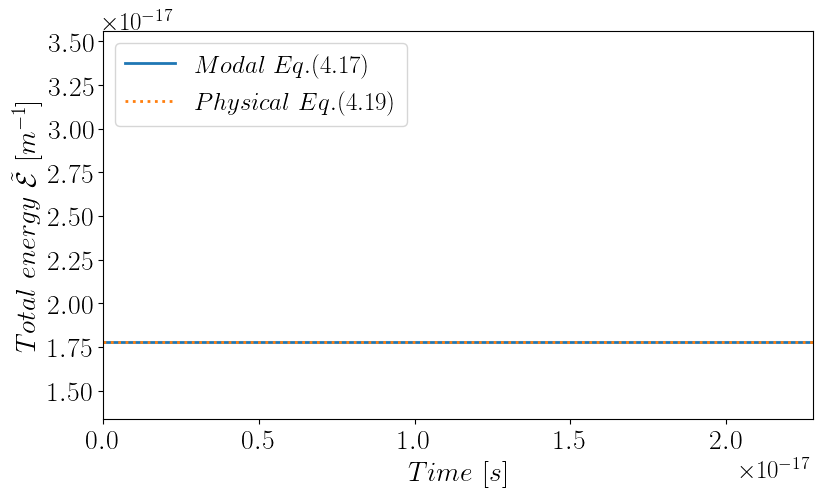

0
1
2
3


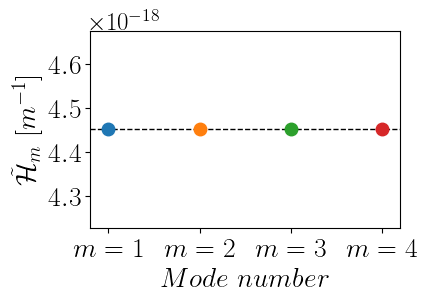

[1. 1. 1. 1.]


In [9]:

qq0 = C1*omegana0**2*lam**2/(2*np.pi**2)
qq1 = C1*omegana1**2*lam**2/(2*np.pi**2)
qq2 = C1*omegana2**2*lam**2/(2*np.pi**2)
qq3 = C1*omegana3**2*lam**2/(2*np.pi**2)

phi_max = np.pi  # Range for φ
num_points = 2000
phi = np.linspace(-phi_max, phi_max, num_points)

nn = 0
chi0 = np.sqrt(2)*(qq0)**0.25*(phi/2)
p_monic0 = sp.hermite(nn, monic=True)
eigenvectors0 = p_monic0(chi0)*np.exp(-np.sqrt(qq0)*(phi/2)**2)*((2*np.sqrt(qq0)/np.pi)**(0.25))/(cm.sqrt(2**nn*sp.factorial(int(nn))))

nn = 1
chi1 = np.sqrt(2)*(qq1)**0.25*(phi/2)
p_monic1 = sp.hermite(nn, monic=True)
eigenvectors1 = p_monic1(chi1)*np.exp(-np.sqrt(qq1)*(phi/2)**2)*((2*np.sqrt(qq1)/np.pi)**(0.25))/(cm.sqrt(2**nn*sp.factorial(int(nn))))

nn = 2
chi2 = np.sqrt(2)*(qq2)**0.25*(phi/2)
p_monic2 = sp.hermite(nn, monic=True)
eigenvectors2 = p_monic2(chi2)*np.exp(-np.sqrt(qq2)*(phi/2)**2)*((2*np.sqrt(qq2)/np.pi)**(0.25))/(cm.sqrt(2**nn*sp.factorial(int(nn))))

nn = 3
chi3 = np.sqrt(2)*(qq3)**0.25*(phi/2)
p_monic3 = sp.hermite(nn, monic=True)
eigenvectors3 = p_monic3(chi3)*np.exp(-np.sqrt(qq3)*(phi/2)**2)*((2*np.sqrt(qq3)/np.pi)**(0.25))/(cm.sqrt(2**nn*sp.factorial(int(nn))))




# ====================== Plots ======================
N = 4
fonty = 17
fig, ax2 = plt.subplots(figsize=(6,4))
plt.rc('text', usetex=True)


# Twin axis for F(x)
ax1 = ax2.twinx()
ax2.tick_params(axis='x', labelsize=fonty)
ax2.tick_params(axis='y', labelsize=fonty)
ax2.plot(x, FFF, 'k--', linewidth=1,alpha=0.5)
ax2.axhline(y=0, color='k',linestyle='--',linewidth=1., alpha=0.5)      
ax2.set_ylabel(r"$F(x)$ $[s^2/m^2]$", fontsize=fonty)
#ax2.legend(loc="upper left")
   

# Store plotted lines to extract their colors
lines = []
for n in range(N):
    line, = ax1.plot(x, Phi_L2[:, n],
                     label=fr"$\phi_{n+1}(x)$",
                     linewidth=2.5)
    lines.append(line)

ax1.plot(lam/2+(lam/np.pi)*phi/2, np.max(Phi_L2[:, 0])*eigenvectors0/np.max(eigenvectors0),'k-',
                     label=fr"$Eq.$ $(3.14)$",linewidth=0.5)    
ax1.plot(lam/2+(lam/np.pi)*phi/2, np.max(Phi_L2[:, 1])*eigenvectors1/np.max(eigenvectors1),'k-',
                     linewidth=0.5)   
ax1.plot(lam/2+(lam/np.pi)*phi/2, np.max(Phi_L2[:, 2])*eigenvectors2/np.max(eigenvectors2),'k-',
                     linewidth=0.5)    
ax1.plot(lam/2+(lam/np.pi)*phi/2, np.max(Phi_L2[:, 3])*eigenvectors3/np.max(eigenvectors3),'k-',
                     linewidth=0.5)   

    
ax1.tick_params(axis='x', labelsize=fonty)
ax1.tick_params(axis='y', labelsize=fonty)
ax2.set_xlabel(r'$x$ $[m]$', fontsize=fonty)
ax1.set_ylabel(r'$Mode$ $\tilde{\phi}_m(x)$ $[m^{-1/2}]$', fontsize=fonty)
ax1.legend(loc="upper left",fontsize=fonty-4)
ax1.set_xlim(-100e-9*0.05, 100e-9+100e-9*0.05)

# First legend: Phi modes
handles, labels = ax1.get_legend_handles_labels()

phi_handles = handles[:-1]   # all except last
phi_labels  = labels[:-1]

leg1 = ax1.legend(phi_handles, phi_labels,
                  loc="upper left",
                  fontsize=fonty-4)
ax1.add_artist(leg1)

# Second legend: QHO curve(s)
qho_handles = handles[-1:]
qho_labels  = labels[-1:]

ax1.legend(qho_handles, qho_labels,
           loc="lower right",
           fontsize=fonty-4)


#ax = plt.gca()
ax1.xaxis.get_offset_text().set_fontsize(fonty-4)
ax1.yaxis.get_offset_text().set_fontsize(fonty-4)
ax2.yaxis.get_offset_text().set_fontsize(fonty-4)


# Add box boundaries
ax1.axvline(0, color="black", lw=3)
ax1.axvline(m*lam, color="black", lw=3)

#plt.title(f"First {N} modes and permittivity profile $F(x)$")
plt.tight_layout()
plt.show()


fig.savefig('Modesfinite_quantum_onewavelength.png', format='png', dpi=1000, bbox_inches='tight')






fig1, ax2 = plt.subplots(figsize=(6,4))
plt.rc('text', usetex=True)


# Twin axis for F(x)
ax1 = ax2.twinx()
ax2.tick_params(axis='x', labelsize=fonty)
ax2.tick_params(axis='y', labelsize=fonty)
ax2.plot(x, FFF, 'k--', linewidth=1,alpha=0.5)
ax2.axhline(y=0, color='k',linestyle='--',linewidth=1., alpha=0.5)      
ax2.set_ylabel(r"$F(x)$ $[s^2/m^2]$", fontsize=fonty)
#ax2.legend(loc="upper left")
    
# Store plotted lines to extract their colors
lines = []
snap_idx = np.linspace(0, Nt-1, 4, dtype=int)
for si in snap_idx:
    if si < 1:
        line, = ax1.plot(x, u[si],
                label=fr"$t={t[si]:.2e}$",
                linewidth=2)
        lines.append(line)
    else:
        line, = ax1.plot(x, u[si],
                label=fr"$t={t[si]:.2e}$",
                linewidth=2,alpha=0.5)
        lines.append(line)
    
ax1.tick_params(axis='x', labelsize=fonty)
ax1.tick_params(axis='y', labelsize=fonty)
ax2.set_xlabel(r'$x$ $[m]$', fontsize=fonty)
ax1.set_ylabel(r'$u(x,t)$', fontsize=fonty)
ax1.legend(loc="upper left",fontsize=fonty-6)
ax1.set_xlim(-100e-9*0.05, 100e-9+100e-9*0.05)


#ax = plt.gca()
ax2.xaxis.get_offset_text().set_fontsize(fonty-4)
ax1.yaxis.get_offset_text().set_fontsize(fonty-4)
ax2.yaxis.get_offset_text().set_fontsize(fonty-4)


# Add box boundaries
ax1.axvline(0, color="black", lw=1.5)
ax1.axvline(m*lam, color="black", lw=1.5)

#plt.title(f"First {N} modes and permittivity profile $F(x)$")
plt.tight_layout()
plt.show()


fig1.savefig('Evol_disp_HQO_1wavelength_inabox.png', format='png', dpi=1000, bbox_inches='tight')




print(E0)
# -- Plots
fonty = 20
fig5 = plt.figure(5, figsize=(8, 5))
plt.rc('text', usetex=True)

plt.plot(t, E_modal*dx,lw=2., label=r'$Modal$ $Eq.(4.17)$')
plt.plot(t, E_quad*dx, ':', lw=2.,          label=r'$Physical$ $Eq.(4.19)$')


plt.xticks(size=fonty)
plt.yticks(size=fonty)
plt.xlabel(r'$Time$ $[s]$',fontsize=fonty)
plt.ylabel(r'$Total$ $energy$ $\tilde{\mathcal{E}}$ $[m^{-1}]$',fontsize=fonty)
plt.legend(loc="upper left",fontsize=fonty-2); 
plt.tight_layout()
plt.xlim(0,t[-1])
plt.ylim(3*E_modes_0[-1]*dx,8*E_modes_0[-1]*dx)

# Set font size for the offset text
ax = plt.gca()
ax.xaxis.get_offset_text().set_fontsize(fonty-2)
ax.yaxis.get_offset_text().set_fontsize(fonty-2)

plt.show()

fig5.savefig('Energy_evol_HQO_1wavelength_inabox.png', format='png', dpi=1000, bbox_inches='tight')




QQ0 = 2
fonty = 20
fig4 = plt.figure(4, figsize=(4, 2.55))
plt.rc('text', usetex=True)


plt.axhline(y=QQ0**2*(C0+C1)/4,color="black", lw=1.,linestyle='--',label=r'$(\tilde{Q}_0)^2(C_0^A+C_1)/4$')

for b, olist in enumerate(o0_bands, start=0):
    print(b)
    for oo in olist:
        if b < N-1:
            color = lines[b].get_color()  # match mode color
            plt.plot(b,dx*E_modes_0[b],'.',markersize=18., alpha=1,color=color)
        else:
            plt.plot(b,dx*E_modes_0[b],'.',markersize=18., alpha=1,color='tab:red',label=r'$Numerics$')
        
#plt.plot(pick,E_modes_0[pick],'.',markersize=15)         
#plt.legend(loc="upper left",fontsize=fonty-2)    
plt.xlabel(r'$Mode$ $number$',fontsize=fonty)
plt.ylabel(r'$\tilde{\mathcal{H}}_m$ $[m^{-1}]$',fontsize=fonty)
plt.xticks(size=fonty)
plt.yticks(size=fonty)

# Set font size for the offset text
ax = plt.gca()
ax.xaxis.get_offset_text().set_fontsize(fonty-2)
ax.yaxis.get_offset_text().set_fontsize(fonty-2)

plt.xlim(-0.2, 3.2)   # set the ylim to ymin, ymax
#plt.xlim(0.,40)   # set the ylim to ymin, ymax
plt.ylim(0.95*E_modes_0[-1]*dx, 1.05*E_modes_0[-1]*dx)   # set the ylim to ymin, ymax
#plt.grid()
plt.yscale('linear')
plt.xticks([0,1,2, 3], [r'$m=1$',r'$m=2$',r'$m=3$',r'$m=4$'])
fig4 = plt.gcf()
plt.show()

fig4.savefig('Energy_per_mode_evol_HQO_1wavelength_inabox.png', format='png', dpi=1000, bbox_inches='tight')



print(np.sqrt(np.trapz(Phi_L2**2, x, axis=0)))

### → Figure 5c — Two-wavelength box ($L = 2\lambda$, $P = 2$)

Same analysis with a box of length $L = 2\lambda$ containing two unit cells.
Shows the doubling of eigenfrequencies per pass band.
Produces `Modesfinite_quantum_twowavelengths.png` and `Evol_disp_HQO_2wavelengths_inabox.png`.


In [10]:
from matplotlib.ticker import ScalarFormatter


# ---------------- parameters ------------------------------------------
eps0 = 8.854e-12
mu0 = 1.25663706127e-6
lam        = 50e-9            # period
m          = 2              # periods  -> m modes per band
n_bands    = 2              # how many bands to keep
ppp        = 300            # grid density
C0       =  -eps0*mu0          # background -1.5 was the first value
#C0 = C01
C1       = np.abs(C0)*1.4           # modulation (gives ε min ≈ -1.5 < 0)
#C1 = C11
# ----------------------------------------------------------------------

# ---------------- run --------------------------------------------------
x, FFF, o0_bands, Phi_bands, bands, sig = slab_indefinite(
        C0, C1, lam, m, ppp, n_bands)

#print(np.concatenate(o0_bands))

print(o0_bands)

omegana0 = 0.5*2*np.pi*np.sqrt(2*C1)/((C0+C1)*lam)
omegana1 = 1.5*2*np.pi*np.sqrt(2*C1)/((C0+C1)*lam)
omegana2 = 2.5*2*np.pi*np.sqrt(2*C1)/((C0+C1)*lam)
omegana3 = 3.5*2*np.pi*np.sqrt(2*C1)/((C0+C1)*lam)
omegana4 = 4.5*2*np.pi*np.sqrt(2*C1)/((C0+C1)*lam)
omegana5 = 5.5*2*np.pi*np.sqrt(2*C1)/((C0+C1)*lam)
print(omegana0,omegana1,omegana2,omegana3,omegana4,omegana5)

qq0 = C1*omegana0**2*lam**2/(2*np.pi**2)
print(2*qq0)

# ---- print nice summary ------------------------------------------
print(f"Periodic slab: C0 = {C0},  C1 = {C1},  λ = {lam}")
for b, olist in enumerate(o0_bands, start=1):
    txt = ", ".join(f"{oo:.5f}" for oo in olist)
    print(f"Pass‑band {b:>2d}:  o0 = [{txt}]")

# --- Plot first N modes along with F(x) on a twin y-axis
N = 4  # Number of modes to plot
#FFF = f_base_physical(x % lam, C0, C1, lam)

# ---------- You already have ε-normalized eigenmodes ----------
Phi_eps = np.hstack(Phi_bands)          # (Nx, K)  columns are eigenmodes
omega   = np.concatenate(o0_bands)      # (K,)
Nx, K   = Phi_eps.shape

# ---------- Make an L2-rescaled copy (per column only) ----------
# Use simple trapz for L2; (optionally) trapezoid weights W if you prefer.
l2 = np.sqrt(np.trapz(Phi_eps**2, x, axis=0))   # shape (K,)
Phi_L2 = Phi_eps / l2                           # still exact eigenvectors


# (Sanity) M-orthogonality off-diagonals stay ~0; diagonals are not ±1 anymore
Mmat    = np.diag(FFF[1:-1])
Phi_int = Phi_L2[1:-1, :]
S = Phi_int.T @ (Mmat @ Phi_int)                # Φᵀ M Φ   (K,K)
# Build T on interior exactly as in your solver
dx   = x[1] - x[0]
Nint = Phi_int.shape[0]
main =  2.0*np.ones(Nint)/dx**2
off  = -1.0*np.ones(Nint-1)/dx**2
Tmat = np.diag(main) + np.diag(off,1) + np.diag(off,-1)
Kmat = Phi_int.T @ (Tmat  @ Phi_int)            # Φᵀ T Φ   (K,K)

# (Optional) verify eigen relation still holds (it does; scaling doesn’t change it)
res = Tmat @ Phi_int - Mmat @ (Phi_int * (omega**2))
rel_inf = np.linalg.norm(res, np.inf) / (np.linalg.norm(Tmat @ Phi_int, np.inf) + 1e-300)
print("eig residual (rel inf) after L2 rescale =", f"{rel_inf:.3e}")



# ---------- Choose initial modal amplitudes using L2 interpretation ----------
# --- Choose initial modal amplitudes q(0)
u0 = 1*(Phi_eps[:, 0]/omega[0]+Phi_eps[:, 1]/omega[1]+Phi_eps[:, 2]/omega[2] + Phi_eps[:, 3]/omega[3])
#u0 = 1*(Phi_eps[:, 0]/omega[0]+ Phi_eps[:, 3]/omega[3])
q_eps = np.trapz(FFF[:, None] * u0[:, None] * Phi_eps, x, axis=0)
print(q_eps)
qL2 = q_eps * l2                               # D^{-1} q_eps
print(qL2)

# Field consistency check
u_from_eps = Phi_eps @ q_eps
u_from_L2  = Phi_L2  @ (l2 * q_eps)    # must match u_from_eps
print("||u_eps - u_L2|| / ||u_eps|| =",
      np.linalg.norm(u_from_eps - u_from_L2) / (np.linalg.norm(u_from_eps) + 1e-300))


# Example: equal-energy-by-displacement: q_n(0) = 1/ω_n (you can choose any rule)
q0  = np.zeros(K)
pick = [0,1,2, 3] # modes you want
q0[pick] = 2.0 / omega[pick]
print(q0)
dq0 = np.zeros_like(q0)

# ---------- Reconstruct fields and compute energy (normalization-agnostic) ----------
# Time evolution (decoupled cosines) is valid since columns are still eigenvectors
Tfinal = 2*np.pi/omegana3
Nt = 1000
t  = np.linspace(0.0, Tfinal, Nt)
q  = q0 * np.cos(np.outer(t, omega))            # (Nt,K)
dq = -q0 * omega * np.sin(np.outer(t, omega))   # (Nt,K)
qL2  = qL2 * np.cos(np.outer(t, omega))            # (Nt,K)
dqL2 = -qL2 * omega * np.sin(np.outer(t, omega))   # (Nt,K)

# Energy via general modal form (works for ANY normalization)
E_modal = 0.5 * (np.einsum('ti,ij,tj->t', dq, S, dq) +
                 np.einsum('ti,ij,tj->t',  q, Kmat, q))

# (Cross-check) energy via physical-space quadratic form
u  = q @ Phi_eps.T                                      # (Nt, Nx)
ut = dq @ Phi_eps.T                                     # (Nt, Nx)
uL2  = qL2 @ Phi_L2.T                                      # (Nt, Nx)
utL2 = dqL2 @ Phi_L2.T                                     # (Nt, Nx)
u_int  = q  @ Phi_int.T
ut_int = dq @ Phi_int.T
E_quad = 0.5 * (np.einsum('ti,ij,tj->t', ut_int, Mmat, ut_int) +
                np.einsum('ti,ij,tj->t',  u_int,  Tmat,  u_int))


E0 = E_quad[0]
print(f"[Energy check] max|E_modal - E_quad| / E0 = {np.max(np.abs(E_modal - E_quad))/E0:.3e}")
print(f"[Energy check] rel variation of E_quad   = {np.ptp(E_quad)/E0:.3e}")

# ---------- Per-mode energy at t=0 (with dq0=0) ----------
# For exact eigenvectors: Kmat ≈ S @ diag(ω^2), so E_n(0) ≈ 0.5 * S_nn * (1)
E_modes_0 = 0.5 * (q0**2) * np.diag(Kmat)
print("E per selected mode at t=0:", E_modes_0[pick])
print("S_nn for selected modes   :", np.diag(S)[pick])



/var/folders/xc/bmsk3vw13cg973pbrrv1dh6c0000gn/T/ipykernel_29253/2584905266.py:62: RuntimeWarning: invalid value encountered in sqrt
  idx    = np.argsort(np.sqrt(lam_r))


max |S_nn−1| = 1.7763568394002505e-15
max |S_nm| (n≠m) = 1.01694087956855e-15
[array([7.87986884e+16, 7.87987118e+16]), array([2.36384726e+17, 2.36384726e+17])]
7.879963428435232e+16 2.36398902853057e+17 3.9399817142176166e+17 5.5159743999046637e+17 7.09196708559171e+17 8.667959771278756e+17
24.500000000000007
Periodic slab: C0 = -1.1126264540484579e-17,  C1 = 1.557677035667841e-17,  λ = 5e-08
Pass‑band  1:  o0 = [78798688392500336.00000, 78798711756063120.00000]
Pass‑band  2:  o0 = [236384725575242144.00000, 236384725575608128.00000]
eig residual (rel inf) after L2 rescale = 2.185e-09
[1.26905666e-17 1.26905628e-17 4.23039178e-18 4.23039178e-18]
[8.50724137e-09 8.50721769e-09 2.83581488e-09 2.83581488e-09]
||u_eps - u_L2|| / ||u_eps|| = 1.0127606686603334e-16
[2.53811331e-17 2.53811256e-17 8.46078356e-18 8.46078356e-18]
[Energy check] max|E_modal - E_quad| / E0 = 9.615e-14
[Energy check] rel variation of E_quad   = 2.831e-12
E per selected mode at t=0: [5.34067013e-08 5.34069669e-08 5

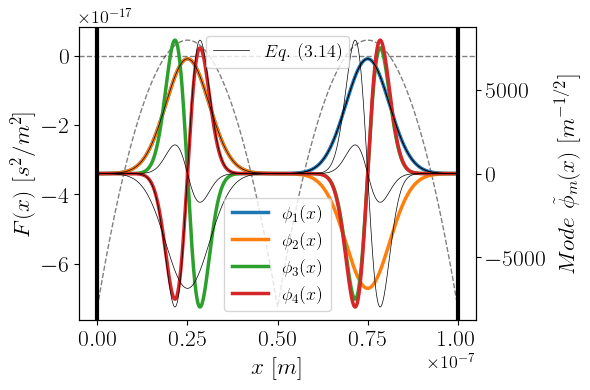

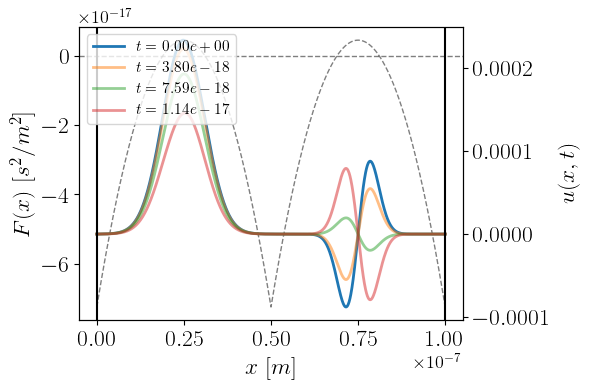

2.1363221437247485e-07


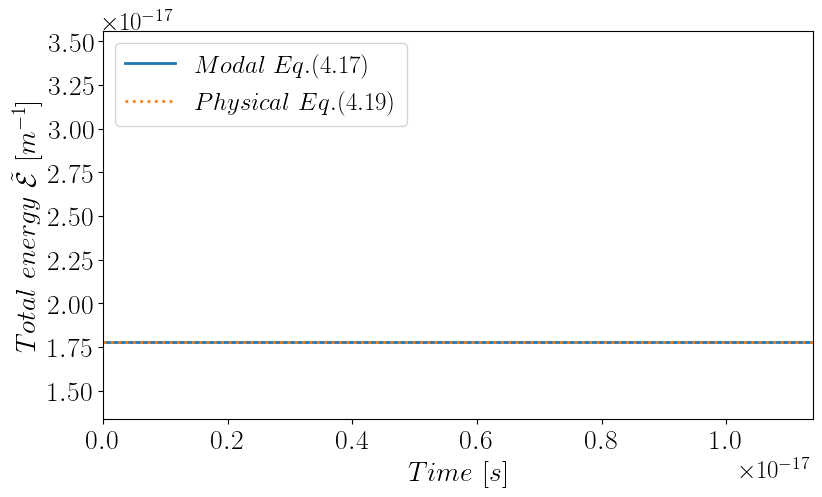

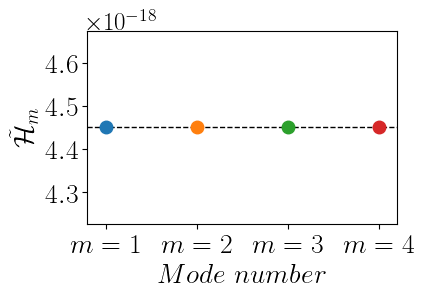

[1. 1. 1. 1.]


In [11]:
qq0 = C1*omegana0**2*lam**2/(2*np.pi**2)
qq1 = C1*omegana1**2*lam**2/(2*np.pi**2)

phi_max = np.pi  # Range for φ
num_points = 2000
phi = np.linspace(-phi_max, phi_max, num_points)

nn = 0
chi0 = np.sqrt(2)*(qq0)**0.25*(phi/2)
p_monic0 = sp.hermite(nn, monic=True)
eigenvectors0 = p_monic0(chi0)*np.exp(-np.sqrt(qq0)*(phi/2)**2)*((2*np.sqrt(qq0)/np.pi)**(0.25))/(cm.sqrt(2**nn*sp.factorial(int(nn))))

nn = 1
chi1 = np.sqrt(2)*(qq1)**0.25*(phi/2)
p_monic1 = sp.hermite(nn, monic=True)
eigenvectors1 = p_monic1(chi1)*np.exp(-np.sqrt(qq1)*(phi/2)**2)*((2*np.sqrt(qq1)/np.pi)**(0.25))/(cm.sqrt(2**nn*sp.factorial(int(nn))))




# ====================== Plots ======================

fonty = 17
fig, ax2 = plt.subplots(figsize=(6,4))
plt.rc('text', usetex=True)


# Twin axis for F(x)
ax1 = ax2.twinx()
ax2.tick_params(axis='x', labelsize=fonty)
ax2.tick_params(axis='y', labelsize=fonty)
ax2.plot(x, FFF, 'k--', linewidth=1,alpha=0.5)
ax2.axhline(y=0, color='k',linestyle='--',linewidth=1., alpha=0.5)      
ax2.set_ylabel(r"$F(x)$ $[s^2/m^2]$", fontsize=fonty)
#ax2.legend(loc="upper left")
    
# Store plotted lines to extract their colors
lines = []
for n in range(N):
    line, = ax1.plot(x, Phi_L2[:, n],
                     label=fr"$\phi_{n+1}(x)$",
                     linewidth=2.5)
    lines.append(line)

ax1.plot(lam/2+(lam/np.pi)*phi/2, np.max(Phi_L2[:, 0])*eigenvectors0/np.max(eigenvectors0),'k-',
                     label=fr"$Eq.$ $(3.14)$",linewidth=0.5)    
ax1.plot(lam/2+(lam/np.pi)*phi/2, -np.max(Phi_L2[:, 1])*eigenvectors0/np.max(np.abs(eigenvectors0)),'k-',
                     linewidth=0.5)   
ax1.plot(lam/2+(lam/np.pi)*phi/2, -0.215*np.max(Phi_L2[:, 2])*eigenvectors1/np.max(eigenvectors1),'k-',
                     linewidth=0.5)   
ax1.plot(lam/2+(lam/np.pi)*phi/2, np.max(Phi_L2[:, 3])*eigenvectors1/np.max(eigenvectors1),'k-',
                     linewidth=0.5)   


ax1.plot(3*lam/2+(lam/np.pi)*phi/2, np.max(Phi_L2[:, 0])*eigenvectors0/np.max(eigenvectors0),'k-',
                     linewidth=0.5)    
ax1.plot(3*lam/2+(lam/np.pi)*phi/2, np.max(Phi_L2[:, 1])*eigenvectors0/np.max(np.abs(eigenvectors0)),'k-',
                     linewidth=0.5)   
ax1.plot(3*lam/2+(lam/np.pi)*phi/2, -np.max(Phi_L2[:, 2])*eigenvectors1/np.max(eigenvectors1),'k-',
                     linewidth=0.5)   
ax1.plot(3*lam/2+(lam/np.pi)*phi/2, -0.215*np.max(Phi_L2[:, 3])*eigenvectors1/np.max(eigenvectors1),'k-',
                     linewidth=0.5)   


    
ax1.tick_params(axis='x', labelsize=fonty)
ax1.tick_params(axis='y', labelsize=fonty)
ax2.set_xlabel(r'$x$ $[m]$', fontsize=fonty)
ax1.set_ylabel(r'$Mode$ $\tilde{\phi}_m(x)$ $[m^{-1/2}]$', fontsize=fonty)
ax1.legend(loc="lower center",fontsize=fonty-4)
ax1.set_xlim(-100e-9*0.05, 100e-9+100e-9*0.05)

# First legend: Phi modes
handles, labels = ax1.get_legend_handles_labels()

phi_handles = handles[:-1]   # all except last
phi_labels  = labels[:-1]

leg1 = ax1.legend(phi_handles, phi_labels,
                  loc="lower center",
                  fontsize=fonty-4)
ax1.add_artist(leg1)

# Second legend: QHO curve(s)
qho_handles = handles[-1:]
qho_labels  = labels[-1:]

ax1.legend(qho_handles, qho_labels,
           loc="upper center",
           fontsize=fonty-4)

#ax = plt.gca()
ax2.xaxis.get_offset_text().set_fontsize(fonty-4)
ax1.yaxis.get_offset_text().set_fontsize(fonty-4)
ax2.yaxis.get_offset_text().set_fontsize(fonty-4)


# Add box boundaries
ax1.axvline(0, color="black", lw=3)
ax1.axvline(m*lam, color="black",lw=3)

#plt.title(f"First {N} modes and permittivity profile $F(x)$")
plt.tight_layout()
plt.show()

fig.savefig('Modesfinite_quantum_twowavelengths.png', format='png', dpi=1000, bbox_inches='tight')










fig1, ax2 = plt.subplots(figsize=(6,4))
plt.rc('text', usetex=True)


# Twin axis for F(x)
ax1 = ax2.twinx()
ax2.tick_params(axis='x', labelsize=fonty)
ax2.tick_params(axis='y', labelsize=fonty)
ax2.plot(x, FFF, 'k--', linewidth=1,alpha=0.5)
ax2.axhline(y=0, color='k',linestyle='--',linewidth=1., alpha=0.5)      
ax2.set_ylabel(r"$F(x)$ $[s^2/m^2]$", fontsize=fonty)
#ax2.legend(loc="upper left")
    
# Store plotted lines to extract their colors
lines = []
snap_idx = np.linspace(0, Nt-1, 4, dtype=int)
for si in snap_idx:
    if si < 1:
        #ax1.plot(x, uL2[si],
        #        label=fr"$t={t[si]:.2e}$",
        #        linewidth=2)
        line, = ax1.plot(x, u[si],
                label=fr"$t={t[si]:.2e}$",
                linewidth=2)
        lines.append(line)
    else:
        #ax1.plot(x, uL2[si],
        #        label=fr"$t={t[si]:.2e}$",
        #        linewidth=2)
        line, = ax1.plot(x, u[si],
                label=fr"$t={t[si]:.2e}$",
                linewidth=2,alpha=0.5)
        lines.append(line)
    
ax1.tick_params(axis='x', labelsize=fonty)
ax1.tick_params(axis='y', labelsize=fonty)
ax2.set_xlabel(r'$x$ $[m]$', fontsize=fonty)
ax1.set_ylabel(r'$u(x,t)$', fontsize=fonty)
ax1.legend(loc="upper left",fontsize=fonty-6)
ax1.set_xlim(-100e-9*0.05, 100e-9+100e-9*0.05)


#ax = plt.gca()
ax2.xaxis.get_offset_text().set_fontsize(fonty-4)
ax1.yaxis.get_offset_text().set_fontsize(fonty-4)
ax2.yaxis.get_offset_text().set_fontsize(fonty-4)


# Add box boundaries
ax1.axvline(0, color="black", lw=1.5)
ax1.axvline(m*lam, color="black", lw=1.5)

#plt.title(f"First {N} modes and permittivity profile $F(x)$")
plt.tight_layout()
plt.show()

fig1.savefig('Evol_disp_HQO_2wavelengths_inabox.png', format='png', dpi=1000, bbox_inches='tight')





LL = 2*lam
print(E0)
# -- Plots
fonty = 20
fig5 = plt.figure(5, figsize=(8, 5))
plt.rc('text', usetex=True)

plt.plot(t, E_modal*dx,lw=2., label=r'$Modal$ $Eq.(4.17)$')
plt.plot(t, E_quad*dx, ':',lw=2.,           label=r'$Physical$ $Eq.(4.19)$')

plt.xticks(size=fonty)
plt.yticks(size=fonty)
plt.xlabel(r'$Time$ $[s]$',fontsize=fonty)
plt.ylabel(r'$Total$ $energy$ $\tilde{\mathcal{E}}$ $[m^{-1}]$',fontsize=fonty)
plt.legend(loc="upper left",fontsize=fonty-2); 
plt.tight_layout()
plt.xlim(0,t[-1])
plt.ylim(3*E_modes_0[0]*dx,8*E_modes_0[0]*dx)

# Set font size for the offset text
ax = plt.gca()
ax.xaxis.get_offset_text().set_fontsize(fonty-2)
ax.yaxis.get_offset_text().set_fontsize(fonty-2)

plt.show()

fig5.savefig('Energy_evol_HQO_2wavelengths_inabox.png', format='png', dpi=1000, bbox_inches='tight')



QQ0 = 2
fonty = 20
fig4 = plt.figure(4, figsize=(4, 2.5))
plt.rc('text', usetex=True)

plt.axhline(y=QQ0**2*(C0+C1)/4,color="black", lw=1.,linestyle='--',label=r'$(\tilde{Q}_0)^2(C_0^A+C_1)/4$')


flat_array = np.concatenate(o0_bands)  # shape: (total_modes,)
for b, oo in enumerate(flat_array[0:4],start=0):
    if b < N-1:
        color = lines[b].get_color()  # match mode color
        plt.plot(b,dx*E_modes_0[b],'.',markersize=18., alpha=1,color=color)
    else:
        color = lines[b].get_color()  # match mode color
        plt.plot(b,dx*E_modes_0[b],'.',markersize=18., alpha=1,color=color)

#plt.plot(pick,E_modes_0[pick]*dx,'.',markersize=15)         
#plt.legend(loc="upper left",fontsize=fonty-2)    
plt.xlabel(r'$Mode$ $number$',fontsize=fonty)
plt.ylabel(r'$\tilde{\mathcal{H}}_m$',fontsize=fonty)
plt.xticks(size=fonty)
plt.yticks(size=fonty)

# Set font size for the offset text
ax = plt.gca()
ax.xaxis.get_offset_text().set_fontsize(fonty-2)
ax.yaxis.get_offset_text().set_fontsize(fonty-2)

plt.xlim(-0.2, 3.2)   # set the ylim to ymin, ymax
#plt.xlim(0.,40)   # set the ylim to ymin, ymax
plt.ylim(0.95*E_modes_0[0]*dx, 1.05*E_modes_0[0]*dx)   # set the ylim to ymin, ymax
#plt.grid()
plt.yscale('linear')
plt.xticks([0,1,2, 3], [r'$m=1$',r'$m=2$',r'$m=3$',r'$m=4$'])
fig4 = plt.gcf()
plt.show()

fig4.savefig('Energy_per_mode_evol_HQO_2wavelengths_inabox.png', format='png', dpi=1000, bbox_inches='tight')



print(np.sqrt(np.trapz(Phi_L2**2, x, axis=0)))

### → Figure 6 — Concatenated medium: superposition principle

Loads precomputed high-resolution stationary modes (`Mode_mid_ppp300.npy`)
for a box made of two concatenated QHO sub-media with different frequencies.
Demonstrates that the spectrum of the full system equals the union of the
individual spectra. Produces `Modesfinite_quantum_concatenate.png`
and `Eigenvalue_problem_HQO_concatenate.png`.


In [12]:
import numpy as np
from numpy.linalg import eig, inv
import matplotlib.pyplot as plt

# ---------- your original helper, unchanged ---------------------------
# --- Define the profile directly on [0, λ] ---
def f_base_physical(x, C0, C1, lam):
    return (C0 + C1) - 2 * C1 * (np.pi / lam)**2 * (x - lam / 2)**2


# ---------- new "concatenate" driver ----------------------------------
def slab_concat_mid(params_A, params_B, params_C, ppp, n_bands):
    """
    Build   [ medium A | medium B | medium C ]   and solve
    Dirichlet @ x=0, x=L.
    params_* = (C0, C1, lam, m)   for each sub‑medium
    """
    # --- unpack parameters --------------------------------------------
    C0_A, C1_A, lam_A, m_A = params_A
    C0_B, C1_B, lam_B, m_B = params_B
    C0_C, C1_C, lam_C, m_C = params_C
    L_A   = m_A * lam_A
    L_B   = m_B * lam_B
    L_C   = m_C * lam_C
    L     = L_A + L_B + L_C

    # --- global grid ---------------------------------------------------
    Nx    = int(np.round((L / lam_A) * (4*ppp))) + 1   # ≥4 points/period_A
    x     = np.linspace(0, L, Nx)
    dx    = x[1] - x[0]

    # --- piece‑wise F(x)  «« NEW »»
    FFF   = np.ones_like(x)*(C0_A+C1_A)        # air as default (ε=1) in gap + outside
    maskA = x <= L_A
    maskB = (x >= L_A) &  (x <= (L_A+L_B))
    maskC = (x >= (L_A+L_B))
    # Local coordinates for each medium (reset origin for periodicity)
    x_A_local = x[maskA] % lam_A
    x_B_local = (x[maskB] - L_A) % lam_B
    x_C_local = (x[maskC] - (L_A+L_B)) % lam_C
    # Apply profiles
    FFF[maskA] = f_base_physical(x_A_local, C0_A, C1_A, lam_A)
    FFF[maskB] = f_base_physical(x_B_local, C0_B, C1_B, lam_B)  
    FFF[maskC] = f_base_physical(x_C_local, C0_C, C1_C, lam_C)

    # ---------------- assemble stiffness & mass ------------------------
    Nint = Nx - 2                         # interior nodes only
    main =  2.0*np.ones(Nint)   / dx**2
    off  = -1.0*np.ones(Nint-1) / dx**2
    T    = np.diag(main) + np.diag(off,1) + np.diag(off,-1)   # stiffness
    M    = np.diag(FFF[1:-1])                                     # mass

    A    = inv(M) @ T                       # standard but NOT symmetric

    # ----- dense eigen‑solve (general complex) ------------------------
    lam_vals, vec = eig(A)                 # λ may come out complex
    # keep only eigen‑values with tiny imaginary part and λ>0
    tol_im = 1e-10
    #mask   = (np.abs(lam_vals.imag) < tol_im) & (lam_vals.real > 0)
    #lam_r  = lam_vals.real[mask]
    #vec_r  = vec[:, mask]
    lam_r  = lam_vals.real
    vec_r  = vec

    # sort by increasing k0
    idx    = np.argsort(np.sqrt(lam_r))
    lam_r  = lam_r[idx]
    vec_r  = vec_r[:, idx]

    need   = n_bands * (m_A+m_B+m_C)
    lam_r, vec_r = lam_r[:need], vec_r[:, :need]

    # build full Φ with boundary zeros
    Phi = np.zeros((Nx, need))
    Phi[1:-1, :] = vec_r

    # normalise in the indefinite inner product  <f,f>ε = ±1
    sign_diag = np.trapz(FFF[:,None]*Phi**2, x, axis=0)
    Phi /= np.sqrt(np.abs(sign_diag))       # gives ±1 norms
    
    
# --- NEW: ε‑weighted Gram–Schmidt to clean up near‑degenerate modes ---
    for j in range(Phi.shape[1]):
        v = Phi[:, j]
        for k in range(j):                                  # subtract proj
            v -= np.trapz(FFF * Phi[:, k] * v, x) * Phi[:, k]
        v /= np.sqrt(np.abs(np.trapz(FFF * v * v, x)))      # renormalise
        Phi[:, j] = v
    
    omeg0  = np.sqrt(lam_r)
    
    S = np.trapz(FFF[:,None,None]*Phi[:,:,None]*Phi[:,None,:], x, axis=0)
    print("max |S_nn−1| =", np.max(np.abs(np.diag(S)-1)))
    print("max |S_nm| (n≠m) =", np.max(np.abs(S-np.diag(np.diag(S)))))    
    
    # ---------------- split into consecutive blocks of length m --------
    o0_bands  = [omeg0[i*(m_A+m_B+m_C):(i+1)*(m_A+m_B+m_C)]        for i in range(n_bands)]
    Phi_bands = [Phi[:, i*(m_A+m_B+m_C):(i+1)*(m_A+m_B+m_C)]    for i in range(n_bands)]
    
    
    return x, FFF, o0_bands, Phi_bands
        

In [ ]:
from matplotlib.ticker import ScalarFormatter

lam = 100e-9
C0A = -eps0*mu0
C0B = C0A
C0C = -0.5*eps0*mu0
C1 = 1.4*eps0*mu0
# ---- sub‑medium definitions  (same numbers you used) -----------------
medium_A = (C0A, C1, 100e-9, 1)   # eps0, eps1, lam, m
medium_B = (C0B, C1, 50e-9, 2)
medium_C = (C0C, C1, 100e-9, 1)   # eps0, eps1, lam, m

x, FFF, o0_bands, Phi_bands = slab_concat_mid(
        params_A = medium_A,
        params_B = medium_B,
        params_C = medium_C,
        ppp      = 300,
        n_bands  = 2)

print("First omeg0:", np.concatenate(o0_bands))



omegana0 = 0.5*2*np.pi*np.sqrt(2*C1)/((C0C+C1)*lam)
omegana1 = 0.5*2*np.pi*np.sqrt(2*C1)/((C0A+C1)*lam)
omegana2 = 1.5*2*np.pi*np.sqrt(2*C1)/((C0C+C1)*lam)
omegana3 = 0.5*2*np.pi*np.sqrt(2*C1)/((C0B+C1)*(lam/2))
omegana4 = 0.5*2*np.pi*np.sqrt(2*C1)/((C0B+C1)*(lam/2))
omegana5 = 2.5*2*np.pi*np.sqrt(2*C1)/((C0C+C1)*lam)
omegana6 = 1.5*2*np.pi*np.sqrt(2*C1)/((C0A+C1)*lam)
omegana = np.array([omegana0,omegana1,omegana2,omegana3,omegana4,omegana5,omegana6])
#print(omegana0,omegana1,omegana2,omegana3,omegana4,omegana5)

#qq0 = C1*omegana0**2*lam**2/(2*np.pi**2)
#print(2*qq0)

# ---- print nice summary ------------------------------------------
#print(f"Periodic slab: C0 = {C0},  C1 = {C1},  λ = {lam}")
#for b, olist in enumerate(o0_bands, start=1):
#    txt = ", ".join(f"{oo:.5f}" for oo in olist)
#    print(f"Pass‑band {b:>2d}:  o0 = [{txt}]")

# --- Plot first N modes along with F(x) on a twin y-axis
N = 7  # Number of modes to plot
#FFF = f_base_physical(x % lam, C0, C1, lam)

# ---------- You already have ε-normalized eigenmodes ----------
Phi_eps = np.hstack(Phi_bands)          # (Nx, K)  columns are eigenmodes
omega   = np.concatenate(o0_bands)      # (K,)
Nx, K   = Phi_eps.shape

# ---------- Make an L2-rescaled copy (per column only) ----------
# Use simple trapz for L2; (optionally) trapezoid weights W if you prefer.
l2 = np.sqrt(np.trapz(Phi_eps**2, x, axis=0))   # shape (K,)
Phi_L2 = Phi_eps / l2                           # still exact eigenvectors


# (Sanity) M-orthogonality off-diagonals stay ~0; diagonals are not ±1 anymore
Mmat    = np.diag(FFF[1:-1])
Phi_int = Phi_L2[1:-1, :]
S = Phi_int.T @ (Mmat @ Phi_int)                # Φᵀ M Φ   (K,K)
# Build T on interior exactly as in your solver
dx   = x[1] - x[0]
Nint = Phi_int.shape[0]
main =  2.0*np.ones(Nint)/dx**2
off  = -1.0*np.ones(Nint-1)/dx**2
Tmat = np.diag(main) + np.diag(off,1) + np.diag(off,-1)
Kmat = Phi_int.T @ (Tmat  @ Phi_int)            # Φᵀ T Φ   (K,K)

# (Optional) verify eigen relation still holds (it does; scaling doesn’t change it)
res = Tmat @ Phi_int - Mmat @ (Phi_int * (omega**2))
rel_inf = np.linalg.norm(res, np.inf) / (np.linalg.norm(Tmat @ Phi_int, np.inf) + 1e-300)
print("eig residual (rel inf) after L2 rescale =", f"{rel_inf:.3e}")



# ---------- Choose initial modal amplitudes using L2 interpretation ----------
# --- Choose initial modal amplitudes q(0)
u0 = 1*(Phi_eps[:, 0]/omega[0]+Phi_eps[:, 1]/omega[1]+Phi_eps[:, 2]/omega[2] + Phi_eps[:, 3]/omega[3]+Phi_eps[:, 4]/omega[4]+Phi_eps[:, 5]/omega[5]+Phi_eps[:, 6]/omega[6])
#u0 = 1*(Phi_eps[:, 0]/omega[0]+ Phi_eps[:, 3]/omega[3])
q_eps = np.trapz(FFF[:, None] * u0[:, None] * Phi_eps, x, axis=0)
print(q_eps)
qL2 = q_eps * l2                               # D^{-1} q_eps
print(qL2)

# Field consistency check
u_from_eps = Phi_eps @ q_eps
u_from_L2  = Phi_L2  @ (l2 * q_eps)    # must match u_from_eps
print("||u_eps - u_L2|| / ||u_eps|| =",
      np.linalg.norm(u_from_eps - u_from_L2) / (np.linalg.norm(u_from_eps) + 1e-300))


# Example: equal-energy-by-displacement: q_n(0) = 1/ω_n (you can choose any rule)
QQ0 = 2
q0  = np.zeros(K)
pick = [0,1,2, 3,4,5,6] # modes you want
q0[pick] = QQ0 / omega[pick]
print(q0)
dq0 = np.zeros_like(q0)

# ---------- Reconstruct fields and compute energy (normalization-agnostic) ----------
# Time evolution (decoupled cosines) is valid since columns are still eigenvectors
Tfinal = 2*np.pi/np.max(omega)
Nt = 1000
t  = np.linspace(0.0, Tfinal, Nt)
q  = q0 * np.cos(np.outer(t, omega))            # (Nt,K)
dq = -q0 * omega * np.sin(np.outer(t, omega))   # (Nt,K)
qL2  = qL2 * np.cos(np.outer(t, omega))            # (Nt,K)
dqL2 = -qL2 * omega * np.sin(np.outer(t, omega))   # (Nt,K)

# Energy via general modal form (works for ANY normalization)
E_modal = 0.5 * (np.einsum('ti,ij,tj->t', dq, S, dq) +
                 np.einsum('ti,ij,tj->t',  q, Kmat, q))

# (Cross-check) energy via physical-space quadratic form
u  = q @ Phi_eps.T                                      # (Nt, Nx)
ut = dq @ Phi_eps.T                                     # (Nt, Nx)
uL2  = qL2 @ Phi_L2.T                                      # (Nt, Nx)
utL2 = dqL2 @ Phi_L2.T                                     # (Nt, Nx)
u_int  = q  @ Phi_int.T
ut_int = dq @ Phi_int.T
E_quad = 0.5 * (np.einsum('ti,ij,tj->t', ut_int, Mmat, ut_int) +
                np.einsum('ti,ij,tj->t',  u_int,  Tmat,  u_int))


E0 = E_quad[0]
print(f"[Energy check] max|E_modal - E_quad| / E0 = {np.max(np.abs(E_modal - E_quad))/E0:.3e}")
print(f"[Energy check] rel variation of E_quad   = {np.ptp(E_quad)/E0:.3e}")

# ---------- Per-mode energy at t=0 (with dq0=0) ----------
# For exact eigenvectors: Kmat ≈ S @ diag(ω^2), so E_n(0) ≈ 0.5 * S_nn * (1)
E_modes_0 = 0.5 * (q0**2) * np.diag(Kmat)
print(np.diag(Kmat))
print("E per selected mode at t=0:", E_modes_0[pick])
print("S_nn for selected modes   :", np.diag(S)[pick])


with open('Mode_mid_ppp300.npy', 'wb') as f:
    np.save(f, x)
    np.save(f, FFF)
    np.save(f, Phi_L2)
    np.save(f, u_int)
    np.save(f, t)
    np.save(f, E_quad)
    np.save(f, E_modal)
    np.save(f, E_modes_0)
    np.save(f, o0_bands)
    np.save(f, pick)
    np.save(f, omegana)
    np.save(f, QQ0)
    

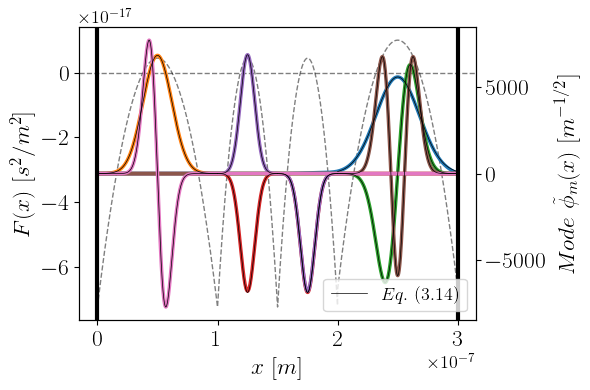

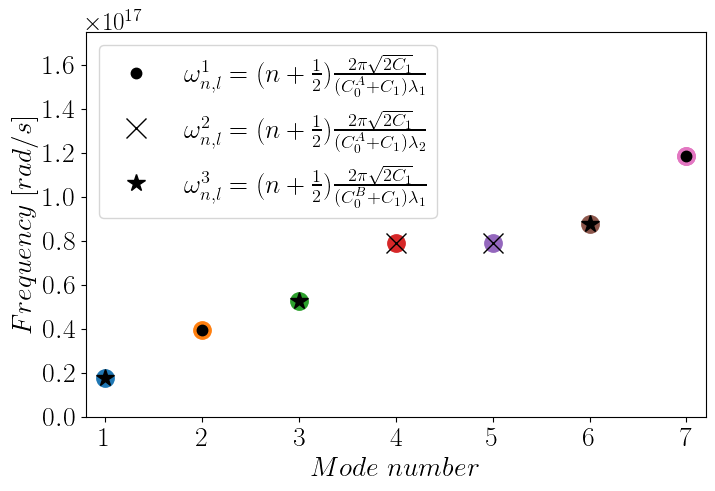

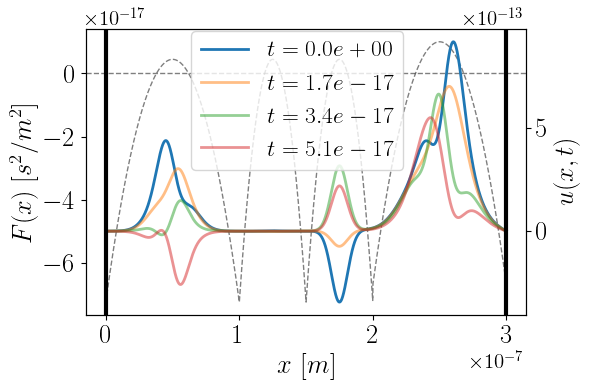

2.1363221437247485e-07 5.750469508285698e-07


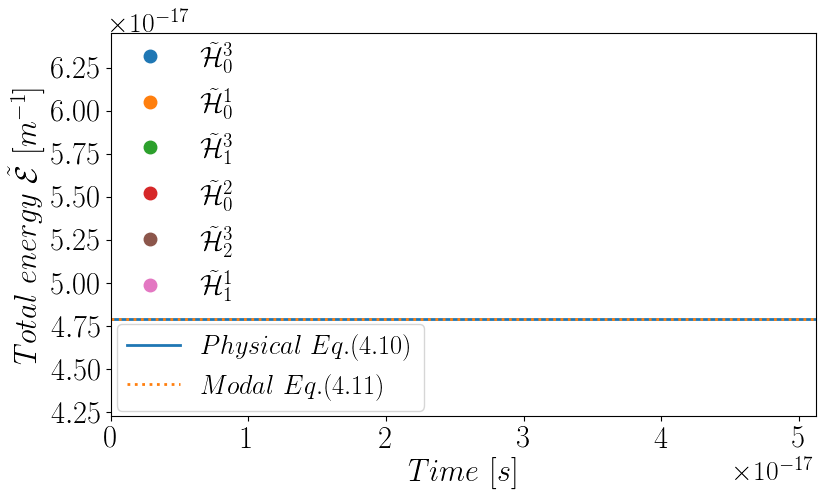

0
1
2
3
4
5
6


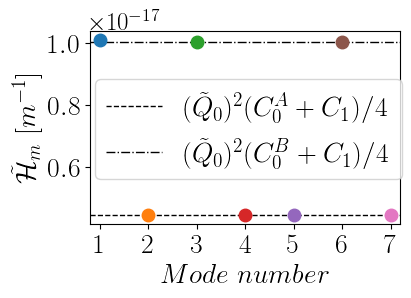

[1. 1. 1. 1. 1. 1. 1. 1.]


In [13]:

with open('Mode_mid_ppp300.npy', 'rb') as f:
    x = np.load(f)
    FFF = np.load(f)
    Phi_L2 = np.load(f)
    u = np.load(f)
    t = np.load(f)
    E_quad = np.load(f)
    E_modal = np.load(f)
    E_modes_0 = np.load(f)
    o0_bands = np.load(f)
    pick = np.load(f)
    omegana = np.load(f)
    QQ0 = np.load(f)

lam = 100e-9
C0A = -eps0*mu0
C0B = C0A
C0C = -0.5*eps0*mu0
C1 = 1.4*eps0*mu0
omegana0 = 0.5*2*np.pi*np.sqrt(2*C1)/((C0C+C1)*lam)
omegana1 = 0.5*2*np.pi*np.sqrt(2*C1)/((C0A+C1)*lam)
omegana2 = 1.5*2*np.pi*np.sqrt(2*C1)/((C0C+C1)*lam)
omegana3 = 0.5*2*np.pi*np.sqrt(2*C1)/((C0B+C1)*(lam/2))
omegana4 = 0.5*2*np.pi*np.sqrt(2*C1)/((C0B+C1)*(lam/2))
omegana5 = 2.5*2*np.pi*np.sqrt(2*C1)/((C0C+C1)*lam)
omegana6 = 1.5*2*np.pi*np.sqrt(2*C1)/((C0A+C1)*lam)
omegana = np.array([omegana0,omegana1,omegana2,omegana3,omegana4,omegana5,omegana6])


qq0 = C1*omegana0**2*lam**2/(2*np.pi**2)
qq1 = C1*omegana1**2*lam**2/(2*np.pi**2)
qq2 = C1*omegana2**2*lam**2/(2*np.pi**2)
qq3 = C1*omegana3**2*(lam/2)**2/(2*np.pi**2)
qq4 = C1*omegana4**2*(lam/2)**2/(2*np.pi**2)
qq5 = C1*omegana5**2*lam**2/(2*np.pi**2)
qq6 = C1*omegana6**2*lam**2/(2*np.pi**2)

phi_max = np.pi  # Range for φ
num_points = 2000
phi = np.linspace(-phi_max, phi_max, num_points)

nn = 0
chi0 = np.sqrt(2)*(qq0)**0.25*(phi/2)
p_monic0 = sp.hermite(nn, monic=True)
eigenvectors0 = p_monic0(chi0)*np.exp(-np.sqrt(qq0)*(phi/2)**2)*((2*np.sqrt(qq0)/np.pi)**(0.25))/(cm.sqrt(2**nn*sp.factorial(int(nn))))

nn=0
chi1 = np.sqrt(2)*(qq1)**0.25*(phi/2)
p_monic1 = sp.hermite(nn, monic=True)
eigenvectors1 = p_monic1(chi1)*np.exp(-np.sqrt(qq1)*(phi/2)**2)*((2*np.sqrt(qq1)/np.pi)**(0.25))/(cm.sqrt(2**nn*sp.factorial(int(nn))))

nn = 1
chi2 = np.sqrt(2)*(qq2)**0.25*(phi/2)
p_monic2 = sp.hermite(nn, monic=True)
eigenvectors2 = p_monic2(chi2)*np.exp(-np.sqrt(qq2)*(phi/2)**2)*((2*np.sqrt(qq2)/np.pi)**(0.25))/(cm.sqrt(2**nn*sp.factorial(int(nn))))


nn = 0
chi3 = np.sqrt(2)*(qq3)**0.25*(phi/2)
p_monic3 = sp.hermite(nn, monic=True)
eigenvectors3 = p_monic3(chi3)*np.exp(-np.sqrt(qq3)*(phi/2)**2)*((2*np.sqrt(qq3)/np.pi)**(0.25))/(cm.sqrt(2**nn*sp.factorial(int(nn))))

nn = 0
chi4 = np.sqrt(2)*(qq4)**0.25*(phi/2)
p_monic4 = sp.hermite(nn, monic=True)
eigenvectors4 = p_monic4(chi4)*np.exp(-np.sqrt(qq4)*(phi/2)**2)*((2*np.sqrt(qq4)/np.pi)**(0.25))/(cm.sqrt(2**nn*sp.factorial(int(nn))))

nn=2
chi5 = np.sqrt(2)*(qq5)**0.25*(phi/2)
p_monic5 = sp.hermite(nn, monic=True)
eigenvectors5 = p_monic5(chi5)*np.exp(-np.sqrt(qq5)*(phi/2)**2)*((2*np.sqrt(qq5)/np.pi)**(0.25))/(cm.sqrt(2**nn*sp.factorial(int(nn))))

nn = 1
chi6 = np.sqrt(2)*(qq6)**0.25*(phi/2)
p_monic6 = sp.hermite(nn, monic=True)
eigenvectors6 = p_monic6(chi6)*np.exp(-np.sqrt(qq6)*(phi/2)**2)*((2*np.sqrt(qq6)/np.pi)**(0.25))/(cm.sqrt(2**nn*sp.factorial(int(nn))))


LL = 100e-9
N = 7

# ====================== Plots ======================

fonty = 17
fig, ax2 = plt.subplots(figsize=(6,4))
plt.rc('text', usetex=True)


# Twin axis for F(x)
ax1 = ax2.twinx()
ax2.tick_params(axis='x', labelsize=fonty)
ax2.tick_params(axis='y', labelsize=fonty)
ax2.plot(x, FFF, 'k--', linewidth=1,alpha=0.5)
ax2.axhline(y=0, color='k',linestyle='--',linewidth=1., alpha=0.5)      
ax2.set_ylabel(r"$F(x)$ $[s^2/m^2]$", fontsize=fonty)
#ax2.legend(loc="upper left")
    
# Store plotted lines to extract their colors
lines = []
for n in range(N):
    line, = ax1.plot(x, Phi_L2[:, n],
                     label=fr"$\phi_{n+1}(x)$",
                     linewidth=2.5)
    lines.append(line)

    
ax1.plot(2*lam+lam/2+(lam/np.pi)*phi/2, np.max(Phi_L2[:, 0])*eigenvectors0/np.max(eigenvectors0),'k-',
                     label=fr"$Eq.$ $(3.14)$",linewidth=0.5)    
ax1.plot(lam/2+(lam/np.pi)*phi/2, np.max(np.abs(Phi_L2[:, 1]))*eigenvectors1/np.max(np.abs(eigenvectors1)),'k-',
                     linewidth=0.5)   
ax1.plot(2*lam+lam/2+(lam/np.pi)*phi/2, np.max(np.abs(Phi_L2[:, 2]))*eigenvectors2/np.max(eigenvectors2),'k-',
                     linewidth=0.5)   
ax1.plot(lam+lam/4+(lam/2/np.pi)*phi/2, -np.max(np.abs(Phi_L2[:, 3]))*eigenvectors3/np.max(eigenvectors3),'k-',
                     linewidth=0.5)   
ax1.plot(lam/2+lam+lam/4+(lam/2/np.pi)*phi/2, -np.max(np.abs(Phi_L2[:, 3]))*eigenvectors3/np.max(eigenvectors3),'k-',
                     linewidth=0.5)   
ax1.plot(lam+lam/4+(lam/2/np.pi)*phi/2, np.max(np.abs(Phi_L2[:, 4]))*eigenvectors3/np.max(eigenvectors4),'k-',
                     linewidth=0.5)   
ax1.plot(lam/2+lam+lam/4+(lam/2/np.pi)*phi/2, -np.max(np.abs(Phi_L2[:, 4]))*eigenvectors3/np.max(eigenvectors4),'k-',
                     linewidth=0.5) 
ax1.plot(2*lam+lam/2+(lam/np.pi)*phi/2, np.max(np.abs(Phi_L2[:, 5]))*eigenvectors5/np.max(eigenvectors5),'k-',
                     linewidth=0.5) 
ax1.plot(lam/2+(lam/np.pi)*phi/2, -np.max(np.abs(Phi_L2[:, 6]))*eigenvectors6/np.max(np.abs(eigenvectors6)),'k-',
                     linewidth=0.5)   
 
ax1.tick_params(axis='x', labelsize=fonty)
ax1.tick_params(axis='y', labelsize=fonty)
ax2.set_xlabel(r'$x$ $[m]$', fontsize=fonty)
ax1.set_ylabel(r'$Mode$ $\tilde{\phi}_m(x)$ $[m^{-1/2}]$', fontsize=fonty)
#ax1.legend(loc="upper left",fontsize=fonty-4)
ax1.legend(loc='lower center',
    bbox_to_anchor=(0.5, 1.08),
    ncol=3,fontsize=fonty-5)
ax2.set_xlim(-3*LL*0.05, 3*LL+3*LL*0.05)

# First legend: Phi modes
handles, labels = ax1.get_legend_handles_labels()

phi_handles = handles[:-1]   # all except last
phi_labels  = labels[:-1]

#leg1 = ax1.legend(phi_handles, phi_labels,
#                  loc="lower center",
#                  fontsize=fonty-4)
#ax1.add_artist(leg1)

# Second legend: QHO curve(s)
qho_handles = handles[-1:]
qho_labels  = labels[-1:]

ax1.legend(qho_handles, qho_labels,
           loc="lower right",
           fontsize=fonty-4)


#ax = plt.gca()
ax2.xaxis.get_offset_text().set_fontsize(fonty-4)
ax1.yaxis.get_offset_text().set_fontsize(fonty-4)
ax2.yaxis.get_offset_text().set_fontsize(fonty-4)


# Add box boundaries
ax1.axvline(0, color="black", lw=3)
ax1.axvline(3*LL, color="black", lw=3)

#plt.title(f"First {N} modes and permittivity profile $F(x)$")
plt.tight_layout()
plt.show()

fig.savefig('Modesfinite_quantum_concatenate.png', format='png', dpi=1000, bbox_inches='tight')




fonty = 20
fig4 = plt.figure(4, figsize=(8, 5))
plt.rc('text', usetex=True)

flat_array = np.concatenate(o0_bands)  # shape: (total_modes,)
for b, oo in enumerate(flat_array[0:N],start=0):
    if b < N-1:
        color = lines[b].get_color()  # match mode color
        plt.plot(b,oo,'.',markersize=25., alpha=1,color=color)
    else:
        color = lines[b].get_color()  # match mode color
        plt.plot(b,oo,'.',markersize=25., alpha=1,color=color)
        
plt.plot(b,oo,'.',markersize=25., alpha=1,color=color)


plt.plot(0,omegana0,'k*',markersize=13)
plt.plot(1,omegana1,'k.',markersize=15,label=r'$\omega^1_{n,l}=(n+\frac{1}{2})\frac{2\pi\sqrt{2C_1}}{(C^A_0+C_1)\lambda_1}$')
plt.plot(2,omegana2,'k*',markersize=13)
plt.plot(3,omegana3,'kx',markersize=15,label=r'$\omega^2_{n,l}=(n+\frac{1}{2})\frac{2\pi\sqrt{2C_1}}{(C^A_0+C_1)\lambda_2}$')
plt.plot(4,omegana4,'kx',markersize=15)
plt.plot(5,omegana5,'k*',markersize=13,label=r'$\omega^3_{n,l}=(n+\frac{1}{2})\frac{2\pi\sqrt{2C_1}}{(C^B_0+C_1)\lambda_1}$')
plt.plot(6,omegana6,'k.',markersize=15)
#plt.plot(2,omegana1,'kx',markersize=8)
#plt.plot(3,omegana1,'kx',markersize=8)              
plt.legend(loc="upper left",fontsize=fonty-1)    
plt.xlabel(r'$Mode$ $number$',fontsize=fonty)
plt.ylabel(r'$Frequency$ $[rad/s]$',fontsize=fonty)
plt.xticks(size=fonty)
plt.yticks(size=fonty)

# Set font size for the offset text
ax = plt.gca()
ax.xaxis.get_offset_text().set_fontsize(fonty-2)
ax.yaxis.get_offset_text().set_fontsize(fonty-2)

plt.xlim(-0.2, 6.2)   # set the ylim to ymin, ymax
#plt.xlim(0.,40)   # set the ylim to ymin, ymax
plt.ylim(0., 1.75e17)   # set the ylim to ymin, ymax
#plt.grid()
plt.yscale('linear')
plt.xticks([0,1,2, 3,4,5,6], [r'$1$',r'$2$',r'$3$',r'$4$',r'$5$',r'$6$',r'$7$'])
fig4 = plt.gcf()
plt.show()

fig4.savefig('Eigenvalue_problem_HQO_concatenate.png', format='png', dpi=1000, bbox_inches='tight')










fonty = 19
fig, ax2 = plt.subplots(figsize=(6,4))
plt.rc('text', usetex=True)


# Twin axis for F(x)
ax1 = ax2.twinx()
ax2.tick_params(axis='x', labelsize=fonty)
ax2.tick_params(axis='y', labelsize=fonty)
ax2.plot(x, FFF, 'k--', linewidth=1,alpha=0.5)
ax2.axhline(y=0, color='k',linestyle='--',linewidth=1., alpha=0.5)      
ax2.set_ylabel(r"$F(x)$ $[s^2/m^2]$", fontsize=fonty)
#ax2.legend(loc="upper left")
    
# Store plotted lines to extract their colors
snap_idx = np.linspace(0, Nt-1, 4, dtype=int)
for si in snap_idx:
    if si < 1:
        #ax1.plot(x, uL2[si],
        #        label=fr"$t={t[si]:.2e}$",
        #        linewidth=2)
        ax1.plot(x[1:-1], u[si],
                label=fr"$t={t[si]:.1e}$",
                linewidth=2)
    else:
        #ax1.plot(x, uL2[si],
        #        label=fr"$t={t[si]:.2e}$",
        #        linewidth=2)
        ax1.plot(x[1:-1], u[si],
                label=fr"$t={t[si]:.1e}$",
                linewidth=2,alpha=0.5)
    
ax1.tick_params(axis='x', labelsize=fonty)
ax1.tick_params(axis='y', labelsize=fonty)
ax2.set_xlabel(r'$x$ $[m]$', fontsize=fonty)
ax1.set_ylabel(r'$u(x,t)$', fontsize=fonty)
#ax1.legend(loc="upper left",fontsize=fonty-6)
ax1.legend(loc='center',bbox_to_anchor=(0.48, 0.75),fontsize=fonty-2)
ax2.set_xlim(-3*LL*0.05, 3*LL+3*LL*0.05)


#ax = plt.gca()
ax2.xaxis.get_offset_text().set_fontsize(fonty-4)
ax1.yaxis.get_offset_text().set_fontsize(fonty-4)
ax2.yaxis.get_offset_text().set_fontsize(fonty-4)


# Add box boundaries
ax1.axvline(0, color="black", lw=3)
ax1.axvline(3*LL, color="black", lw=3)

#plt.title(f"First {N} modes and permittivity profile $F(x)$")
plt.tight_layout()
plt.show()

fig.savefig('Evol_disp_HQO_concatenate_inabox.png', format='png', dpi=1000, bbox_inches='tight')






print(E0,np.sum(E_modes_0[pick]))
# -- Plots
fonty = 20
fig5 = plt.figure(5, figsize=(8, 5))
plt.rc('text', usetex=True)

color = lines[0].get_color()
# dummy handle for first legend
h10, = plt.plot(np.NaN, np.NaN, '.', markersize=18., alpha=1,
               color=color, label=r'$\tilde{\mathcal{H}}^3_0$')
color = lines[1].get_color()
# dummy handle for first legend
h11, = plt.plot(np.NaN, np.NaN, '.', markersize=18., alpha=1,
               color=color, label=r'$\tilde{\mathcal{H}}^1_0$')
color = lines[2].get_color()
# dummy handle for first legend
h12, = plt.plot(np.NaN, np.NaN, '.', markersize=18., alpha=1,
               color=color, label=r'$\tilde{\mathcal{H}}^3_1$')
color = lines[3].get_color()
# dummy handle for first legend
h13, = plt.plot(np.NaN, np.NaN, '.', markersize=18., alpha=1,
               color=color, label=r'$\tilde{\mathcal{H}}^2_0$')
color = lines[5].get_color()
# dummy handle for first legend
h14, = plt.plot(np.NaN, np.NaN, '.', markersize=18., alpha=1,
               color=color, label=r'$\tilde{\mathcal{H}}^3_2$')
color = lines[6].get_color()
# dummy handle for first legend
h15, = plt.plot(np.NaN, np.NaN, '.', markersize=18., alpha=1,
               color=color, label=r'$\tilde{\mathcal{H}}^1_1$')

# actual plots
h2, = plt.plot(t, E_quad*dx, lw=2., label=r'$Physical$ $Eq.(4.10)$')
h3, = plt.plot(t, E_modal*dx, ':', lw=2., label=r'$Modal$ $Eq.(4.11)$')

# first legend (upper left, no box)
leg1 = plt.legend(handles=[h10,h11,h12,h13,h14,h15],
                  loc='upper left',
                  bbox_to_anchor=(0, 1.01),  # tweak this
                  fontsize=fonty,
                  frameon=False,
                  borderaxespad=0.)


# keep it when adding second legend
plt.gca().add_artist(leg1)

# second legend (your original one)
plt.legend(handles=[h2, h3],bbox_to_anchor=(-0.01, -0.02), loc='lower left',
           fontsize=fonty-1)

plt.xticks(size=fonty+2)
plt.yticks(size=fonty+2)
plt.xlabel(r'$Time$ $[s]$',fontsize=fonty+2)
plt.ylabel(r'$Total$ $energy$ $\tilde{\mathcal{E}}$ $[m^{-1}]$',fontsize=fonty+2)
#plt.legend(loc="lower left",fontsize=fonty-2); 
plt.tight_layout()
plt.xlim(0,t[-1])
plt.ylim(9.5*E_modes_0[1]*dx,14.5*E_modes_0[1]*dx)

# Set font size for the offset text
ax = plt.gca()
ax.xaxis.get_offset_text().set_fontsize(fonty)
ax.yaxis.get_offset_text().set_fontsize(fonty)

plt.show()

fig5.savefig('Energy_evol_HQO_concatenate_inabox.png', format='png', dpi=1000, bbox_inches='tight')



fonty = 20
fig4 = plt.figure(4, figsize=(4, 2.5))
plt.rc('text', usetex=True)

#plt.axhline(y=1,color="black", lw=1.,linestyle='--',label=r'$C_0^A+C_1$')
#plt.axhline(y=(C0C+C1)/(C0A+C1),color="black", lw=1.,linestyle='-.',label=r'$(C_0^B+C_1)=2.25(C_0^A+C_1)$')
plt.axhline(y=QQ0**2*(C0A+C1)/4,color="black", lw=1.,linestyle='--',label=r'$(\tilde{Q}_0)^2(C_0^A+C_1)/4$')
plt.axhline(y=QQ0**2*(C0C+C1)/4,color="black", lw=1.,linestyle='-.',label=r'$(\tilde{Q}_0)^2(C_0^B+C_1)/4$')


for b, oo in enumerate(flat_array[0:N],start=0):
    if b < N:
        print(b)
        color = lines[b].get_color()  # match mode color
        #plt.plot(b,E_modes_0[b]/E_modes_0[1],'.',markersize=18., alpha=1,color=color)
        plt.plot(b,dx*E_modes_0[b],'.',markersize=18., alpha=1,color=color)

        
plt.legend(
    loc="center right",
    bbox_to_anchor=(1.05, 0.49),
    fontsize=fonty
)   
plt.xlabel(r'$Mode$ $number$',fontsize=fonty)
plt.ylabel(r'$\tilde{\mathcal{H}}_m$ $[m^{-1}]$',fontsize=fonty)
plt.xticks(size=fonty)
plt.yticks(size=fonty)

# Set font size for the offset text
ax = plt.gca()
ax.xaxis.get_offset_text().set_fontsize(fonty-2)
ax.yaxis.get_offset_text().set_fontsize(fonty-2)

plt.xlim(-0.2, 6.2)   # set the ylim to ymin, ymax
#plt.xlim(0.,40)   # set the ylim to ymin, ymax
#plt.ylim(0.8, 2)   # set the ylim to ymin, ymax
#plt.grid()
plt.yscale('linear')
plt.xticks([0,1,2, 3,4,5,6], [r'$1$',r'$2$',r'$3$',r'$4$',r'$5$',r'$6$',r'$7$'])
fig4 = plt.gcf()
plt.show()

fig4.savefig('Energy_per_mode_evol_HQO_concatenate_inabox.png', format='png', dpi=1000, bbox_inches='tight')



print(np.sqrt(np.trapz(Phi_L2**2, x, axis=0)))



### Photon-energy analogy — classical EM field quantum emulator

The following sections implement the full photon-energy analogy (Eq. 45–46 of the paper).
By designing $M$ concatenated QHO sub-cells with prescribed $C_0^{(i)}, C_1^{(i)}$
and initial conditions, the classical electromagnetic energy reproduces
$$E = \sum_{i=1}^{M}\!\left(n_i + \tfrac{1}{2}\right)\hbar\omega_i$$


In [14]:
import numpy as np
from numpy.linalg import eig, inv
import matplotlib.pyplot as plt

# ---------- your original helper, unchanged ---------------------------
# --- Define the profile directly on [0, λ] ---
def f_base_physical(x, C0, C1, lam):
    return (C0 + C1) - 2 * C1 * (np.pi / lam)**2 * (x - lam / 2)**2


# ---------- new "concatenate" driver ----------------------------------
def slab_concat_big(params_A, params_B, params_C, params_D, ppp, n_bands):
    """
    Build   [ medium A | medium B | medium C | medium D ]   and solve
    Dirichlet @ x=0, x=L.
    params_* = (C0, C1, lam, m)   for each sub‑medium
    """
    # --- unpack parameters --------------------------------------------
    C0_A, C1_A, lam_A, m_A = params_A
    C0_B, C1_B, lam_B, m_B = params_B
    C0_C, C1_C, lam_C, m_C = params_C
    C0_D, C1_D, lam_D, m_D = params_D
    L_A   = m_A * lam_A
    L_B   = m_B * lam_B
    L_C   = m_C * lam_C
    L_D   = m_D * lam_D
    L     = L_A + L_B + L_C + L_D

    # --- global grid ---------------------------------------------------
    Nx    = int(np.round((L / lam_A) * (4*ppp))) + 1   # ≥4 points/period_A
    x     = np.linspace(0, L, Nx)
    dx    = x[1] - x[0]

    # --- piece‑wise F(x)  «« NEW »»
    FFF   = np.ones_like(x)*(C0_A+C1_A)        # air as default (ε=1) in gap + outside
    maskA = x <= L_A
    maskB = (x >= L_A) &  (x <= (L_A+L_B))
    maskC = (x >= (L_A+L_B)) &  (x <= (L_A+L_B+L_C))
    maskD = x >= (L_A+L_B+L_C)
    # Local coordinates for each medium (reset origin for periodicity)
    x_A_local = x[maskA] % lam_A
    x_B_local = (x[maskB] - L_A) % lam_B
    x_C_local = (x[maskC] - (L_A+L_B)) % lam_C
    x_D_local = (x[maskD] - (L_A+L_B+L_C)) % lam_D
    # Apply profiles
    FFF[maskA] = f_base_physical(x_A_local, C0_A, C1_A, lam_A)
    FFF[maskB] = f_base_physical(x_B_local, C0_B, C1_B, lam_B)  
    FFF[maskC] = f_base_physical(x_C_local, C0_C, C1_C, lam_C)
    FFF[maskD] = f_base_physical(x_D_local, C0_D, C1_D, lam_D)

    # ---------------- assemble stiffness & mass ------------------------
    Nint = Nx - 2                         # interior nodes only
    main =  2.0*np.ones(Nint)   / dx**2
    off  = -1.0*np.ones(Nint-1) / dx**2
    T    = np.diag(main) + np.diag(off,1) + np.diag(off,-1)   # stiffness
    M    = np.diag(FFF[1:-1])                                     # mass

    A    = inv(M) @ T                       # standard but NOT symmetric

    # ----- dense eigen‑solve (general complex) ------------------------
    lam_vals, vec = eig(A)                 # λ may come out complex
    # keep only eigen‑values with tiny imaginary part and λ>0
    tol_im = 1e-10
    #mask   = (np.abs(lam_vals.imag) < tol_im) & (lam_vals.real > 0)
    #lam_r  = lam_vals.real[mask]
    #vec_r  = vec[:, mask]
    lam_r  = lam_vals.real
    vec_r  = vec

    # sort by increasing k0
    idx    = np.argsort(np.sqrt(lam_r))
    lam_r  = lam_r[idx]
    vec_r  = vec_r[:, idx]

    need   = n_bands * (m_A+m_B+m_C+m_D)
    lam_r, vec_r = lam_r[:need], vec_r[:, :need]

    # build full Φ with boundary zeros
    Phi = np.zeros((Nx, need))
    Phi[1:-1, :] = vec_r

    # normalise in the indefinite inner product  <f,f>ε = ±1
    sign_diag = np.trapz(FFF[:,None]*Phi**2, x, axis=0)
    Phi /= np.sqrt(np.abs(sign_diag))       # gives ±1 norms
    
    
# --- NEW: ε‑weighted Gram–Schmidt to clean up near‑degenerate modes ---
    for j in range(Phi.shape[1]):
        v = Phi[:, j]
        for k in range(j):                                  # subtract proj
            v -= np.trapz(FFF * Phi[:, k] * v, x) * Phi[:, k]
        v /= np.sqrt(np.abs(np.trapz(FFF * v * v, x)))      # renormalise
        Phi[:, j] = v
    
    omeg0  = np.sqrt(lam_r)
    
    S = np.trapz(FFF[:,None,None]*Phi[:,:,None]*Phi[:,None,:], x, axis=0)
    print("max |S_nn−1| =", np.max(np.abs(np.diag(S)-1)))
    print("max |S_nm| (n≠m) =", np.max(np.abs(S-np.diag(np.diag(S)))))    
    
    # ---------------- split into consecutive blocks of length m --------
    o0_bands  = [omeg0[i*(m_A+m_B+m_C+m_D):(i+1)*(m_A+m_B+m_C+m_D)]        for i in range(n_bands)]
    Phi_bands = [Phi[:, i*(m_A+m_B+m_C+m_D):(i+1)*(m_A+m_B+m_C+m_D)]    for i in range(n_bands)]
    
    
    return x, FFF, o0_bands, Phi_bands
        

### → Figure 8 — Ground state ($n_i = 0$ for all $i$)

Loads the precomputed ground-state mode profile
(`Mode_big_ppp300_groundstate_testreal.npy`) and plots the stationary
field distribution and energy spectrum corresponding to all modes
in their quantum ground state. Produces `Modesfinite_quantum_groundstate.png`
and `Eigenvalue_problem_HQO_groundstate.png`.


In [ ]:
from matplotlib.ticker import ScalarFormatter
from scipy.integrate import cumulative_trapezoid

AA = np.pi*(1e-10/100)**2
mu0 = 1.25663706127e-6
hbar = 1.05457182e-34
Lam = 0.025e-9
C0ana = 100
CC1_analytic = (2*np.sqrt(2) + np.sqrt(8 + C0ana))**2
print(C0ana,CC1_analytic)

C0 = -C0ana*eps0*mu0
C1 = CC1_analytic*eps0*mu0


# ---- sub‑medium definitions  (same numbers you used) -----------------
medium_A = (C0, C1, Lam, 1)   # eps0, eps1, lam, m
medium_B = (C0, C1, Lam/2, 2)
medium_C = (C0, C1, Lam/3, 3)   # eps0, eps1, lam, m
medium_D = (C0, C1, Lam/4, 4)

x, FFF, o0_bands, Phi_bands = slab_concat_big(
        params_A = medium_A,
        params_B = medium_B,
        params_C = medium_C,
        params_D = medium_D,
        ppp      = 300,
        n_bands  = 2)

print("First omeg0:", np.concatenate(o0_bands))


# --- Plot first N modes along with F(x) on a twin y-axis
N = 8  # Number of modes to plot
#FFF = f_base_physical(x % lam, C0, C1, lam)

# ---------- You already have ε-normalized eigenmodes ----------
Phi_eps = np.hstack(Phi_bands)          # (Nx, K)  columns are eigenmodes
omega   = np.concatenate(o0_bands)      # (K,)
Nx, K   = Phi_eps.shape

# ---------- Make an L2-rescaled copy (per column only) ----------
# Use simple trapz for L2; (optionally) trapezoid weights W if you prefer.
l2 = np.sqrt(np.trapz(Phi_eps**2, x, axis=0))   # shape (K,)
Phi_L2 = Phi_eps / l2                           # still exact eigenvectors


# (Sanity) M-orthogonality off-diagonals stay ~0; diagonals are not ±1 anymore
Mmat    = np.diag(FFF[1:-1])
Phi_int = Phi_L2[1:-1, :]
S = Phi_int.T @ (Mmat @ Phi_int)                # Φᵀ M Φ   (K,K)
# Build T on interior exactly as in your solver
dx   = x[1] - x[0]
Nint = Phi_int.shape[0]
main =  2.0*np.ones(Nint)/dx**2
off  = -1.0*np.ones(Nint-1)/dx**2
Tmat = np.diag(main) + np.diag(off,1) + np.diag(off,-1)
Kmat = Phi_int.T @ (Tmat  @ Phi_int)            # Φᵀ T Φ   (K,K)

# (Optional) verify eigen relation still holds (it does; scaling doesn’t change it)
res = Tmat @ Phi_int - Mmat @ (Phi_int * (omega**2))
rel_inf = np.linalg.norm(res, np.inf) / (np.linalg.norm(Tmat @ Phi_int, np.inf) + 1e-300)
print("eig residual (rel inf) after L2 rescale =", f"{rel_inf:.3e}")



# ---------- Choose initial modal amplitudes using L2 interpretation ----------
# --- Choose initial modal amplitudes q(0)
u0 = 1*(Phi_eps[:,0]+Phi_eps[:,1]+Phi_eps[:,2]+Phi_eps[:,3]+Phi_eps[:,4]+Phi_eps[:,6]+Phi_eps[:,7]+Phi_eps[:,8]+Phi_eps[:,9]+Phi_eps[:,10])     
q_eps = np.trapz(FFF[:, None] * u0[:, None] * Phi_eps, x, axis=0)
print(q_eps)
qL2 = q_eps * l2                               # D^{-1} q_eps
print(qL2)

# Field consistency check
u_from_eps = Phi_eps @ q_eps
u_from_L2  = Phi_L2  @ (l2 * q_eps)    # must match u_from_eps
print("||u_eps - u_L2|| / ||u_eps|| =",
      np.linalg.norm(u_from_eps - u_from_L2) / (np.linalg.norm(u_from_eps) + 1e-300))


# Example: equal-energy-by-displacement: q_n(0) = 1 (you can choose any rule)
Etilde0 = 2.
Etilde0 = (2*np.pi*vv*mu0*hbar/(1e-10*AA*(C0+C1)))**0.5
q0  = np.zeros(K)
pick = [0,1,2, 3,4,6,7,8,9,10] # modes you want
#q0[pick] = 1.0 / omega[pick]
q0[pick] = Etilde0
print(q0)
dq0 = np.zeros_like(q0)

# ---------- Reconstruct fields and compute energy (normalization-agnostic) ----------
# Time evolution (decoupled cosines) is valid since columns are still eigenvectors
Tfinal = 2*np.pi/np.max(omega)
Nt = 1000
t  = np.linspace(0.0, Tfinal, Nt)
q  = q0 * np.cos(np.outer(t, omega))            # (Nt,K)
dq = -q0 * omega * np.sin(np.outer(t, omega))   # (Nt,K)
qL2  = qL2 * np.cos(np.outer(t, omega))            # (Nt,K)
dqL2 = -qL2 * omega * np.sin(np.outer(t, omega))   # (Nt,K)
        
# --- derivatives of Phi (spatial) on the same grid x
# use central differences (np.gradient handles boundaries)
Phi_x = np.gradient(Phi_L2, x, axis=0)   # shape (Nx, K)
# Note: Phi_x[i,n] ≈ ∂x phi_n(x_i)

# --- time integral of modal q: Qint(t) = ∫_0^t q(s) ds
# use cumulative trapezoid in time
# q is (Nt, K); cumtrapz returns (Nt-1, K) unless initial=0
q_int = cumulative_trapezoid(q, t, axis=0, initial=0.0)   # shape (Nt, K)
# q_int[it] is ∫_0^{t[it]} q(s) ds

# reconstruct E(x,t) in physical space
# E(t,x) = q(t) @ Phi_eps.T  -> shape (Nt, Nx)
E_space = q @ Phi_L2.T    # (Nt, Nx)

# reconstruct B from modal integral:
# B(t,x) = B0(x) + Phi_x @ q_int(t)  => doing as row products:
B_from_modal = q_int @ Phi_x.T    # (Nt, Nx)  (this is the integral-part)
# We impose B(0,x)=B0=0 because dq0 = 0 so
E_quad = 0.5*(AA/mu0)*( np.trapz(FFF[None,:]*E_space**2, x, axis=1)
                   + np.trapz(B_from_modal**2, x, axis=1) )

E_phys0 = E_quad[0]
E_phys_minmax = np.max(E_quad) - np.min(E_quad)
rel_drift = E_phys_minmax / (np.mean(E_quad) + 1e-300)

print("E_phys(0) =", E_phys0)
print("energy absolute drift (max-min) =", E_phys_minmax)
print("energy relative drift (max-min)/mean =", rel_drift)

# if you used B0 = 0, compare to electric-only at t=0
E_elec_at0 = 0.5 * (AA/mu0)* np.trapz(FFF * E_space[0,:]**2, x)
print("0.5*∫eps E^2 at t=0 =", E_elec_at0)
print("abs diff Ephys(0) - E_elec_at0 =", np.abs(E_phys0 - E_elec_at0))
print("relative diff:", np.abs(E_phys0 - E_elec_at0)/(np.abs(E_phys0)+1e-300))   
        
# ---------------------------
# ELECTRIC PART (per mode)
# E_elec = 0.5 * ∫ ε E^2 dx = 0.5 * q.T S q  where S_ij = ∫ ε φ_i φ_j dx
# per-mode attribution: elec_per_mode[n] = 0.5 * q_n * (S q)_n
# ---------------------------
# build S using trapz (consistent with q)
# compute S @ q[t] quickly by precomputing S (KxK)
S2 = np.zeros((K, K))
for i in range(K):
    for j in range(i, K):
        Sij = np.trapz(FFF * Phi_L2[:, i] * Phi_L2[:, j], x)
        S2[i, j] = Sij
        S2[j, i] = Sij

# compute S q for all times: (Nt, K) = q @ S.T
Sq = q @ S2.T   # (Nt, K)

# electric energy per mode time series (Nt, K)
E_elec_per_mode = 0.5 * (AA/mu0)* (q * Sq)    # elementwise: 0.5 * q_n * (S q)_n

# ---------------------------
# MAGNETIC PART (per mode)
# B(t) = B0 + Phi_x @ q_int(t)
# E_mag = 0.5 * ∫ B^2 dx
# expand: E_mag = 0.5*∫B0^2 dx  + ∫ B0 (Phi_x q_int) dx + 0.5 * q_int^T R q_int
# where cB0_n = ∫ B0 * phi_x_n dx  (vector), and R_{nm} = ∫ phi_x_n * phi_x_m dx
# We attribute per-mode contributions:
#   mag_const = 0.5*∫B0^2 dx (scalar)
#   mag_cross_per_mode[n] = 0.5 * 2 * cB0_n * q_int_n  = cB0_n * q_int_n
#   mag_quad_per_mode[n] = 0.5 * q_int_n * (R q_int)_n
# Sum over n gives full magnetic energy minus the constant (mag_const).
# ---------------------------

# compute cB0 (K,) = ∫ B0(x) * phi_x_n(x) dx
if 'B0' not in globals():
    B0 = np.zeros(Nx)

cB0 = np.zeros(K)
for n in range(K):
    cB0[n] = np.trapz(B0 * Phi_x[:, n], x)

# compute R matrix (KxK) = ∫ phi_x_n * phi_x_m dx
R = np.zeros((K, K))
for i in range(K):
    for j in range(i, K):
        Rij = np.trapz(Phi_x[:, i] * Phi_x[:, j], x)
        R[i, j] = Rij
        R[j, i] = Rij

# compute R @ q_int for all times: (Nt, K)
R_qint = q_int @ R.T   # (Nt, K)

# magnetic per-mode contributions (Nt, K)
# cross term (assigned per-mode)
mag_cross_per_mode = (cB0[None, :] * q_int)   # (Nt, K)  <- equals 0.5*2*cB0*q_int
# quadratic part per mode
mag_quad_per_mode = 0.5 * (AA/mu0)* (q_int * R_qint)    # (Nt, K)

# total magnetic per mode (Nt, K)
E_mag_per_mode = mag_cross_per_mode + mag_quad_per_mode   # does NOT include mag_const

# ---------------------------
# TOTAL per-mode energy and checks
# ---------------------------
E_per_mode = E_elec_per_mode + E_mag_per_mode    # (Nt, K)
E_modal = np.sum(E_per_mode,axis=1)
E_modes_0 = E_per_mode[0,:]


with open('Mode_big_ppp300_groundstate_testreal.npy', 'wb') as f:
    np.save(f,C0)
    np.save(f,C1)
    np.save(f, x)
    np.save(f, FFF)
    np.save(f, Phi_L2)
    np.save(f, E_space)
    np.save(f, t)
    np.save(f, E_quad)
    np.save(f, E_modal)
    np.save(f, E_modes_0)
    np.save(f, o0_bands)
    np.save(f, pick)
    

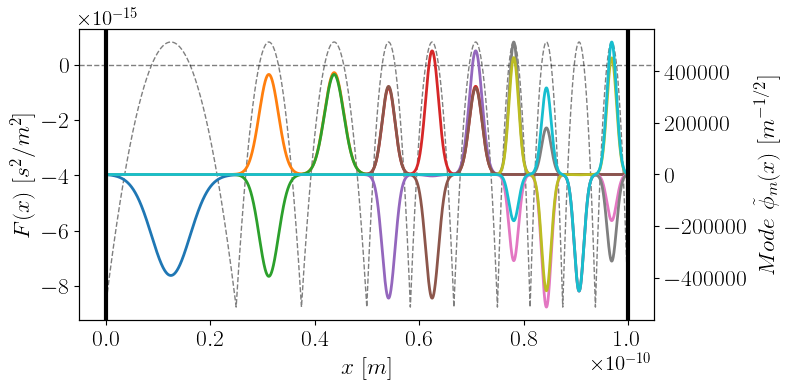

[9.41864117e+18 1.88357807e+19 1.88371998e+19 2.82529486e+19
 2.82544542e+19 2.82547903e+19 2.82559598e+19 3.76699047e+19
 3.76715912e+19 3.76735031e+19 3.76747477e+19 4.70905629e+19
 5.65078834e+19 5.65078834e+19 6.59252039e+19 8.47575819e+19
 8.47575819e+19 8.47575819e+19 8.47582608e+19 9.41737709e+19]


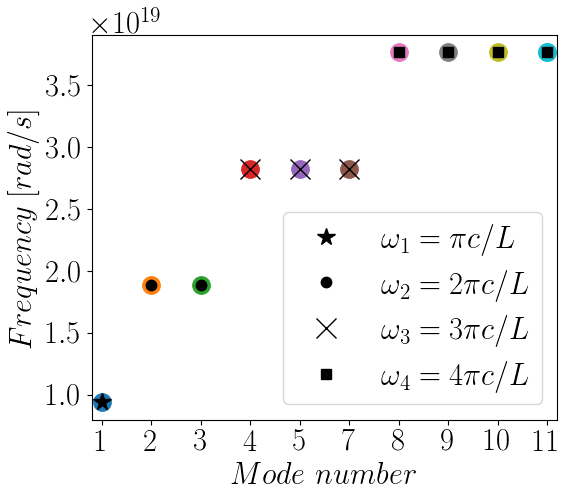

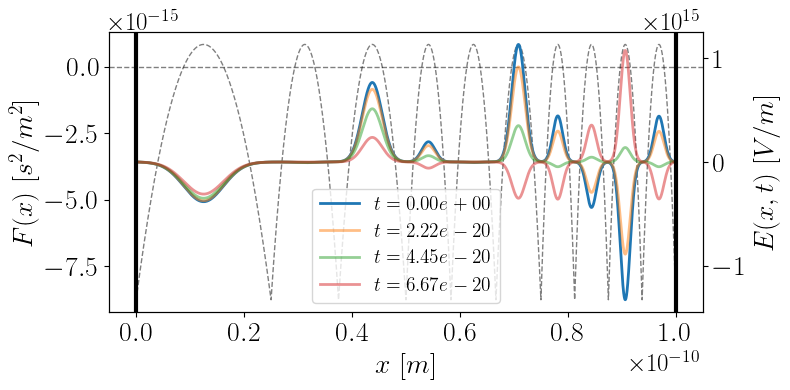

2.1363221437247485e-07 4.96638139328755e-15


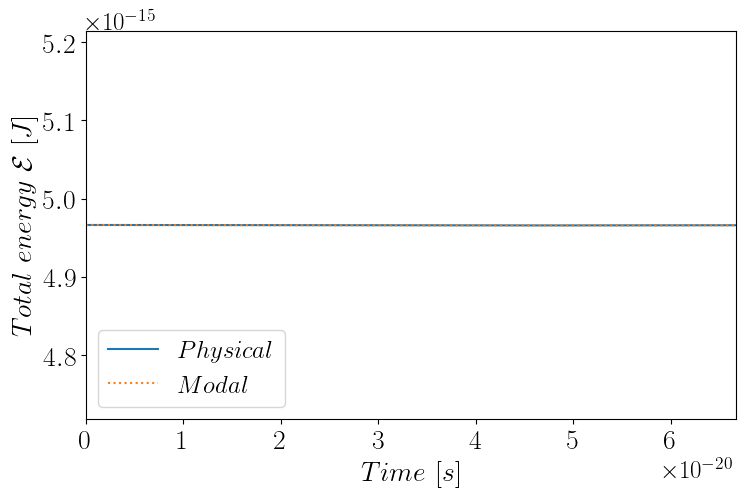

0
0
1
1
2
2
3
3
4
4
5
5
6
6
7
7
8
8
9
9


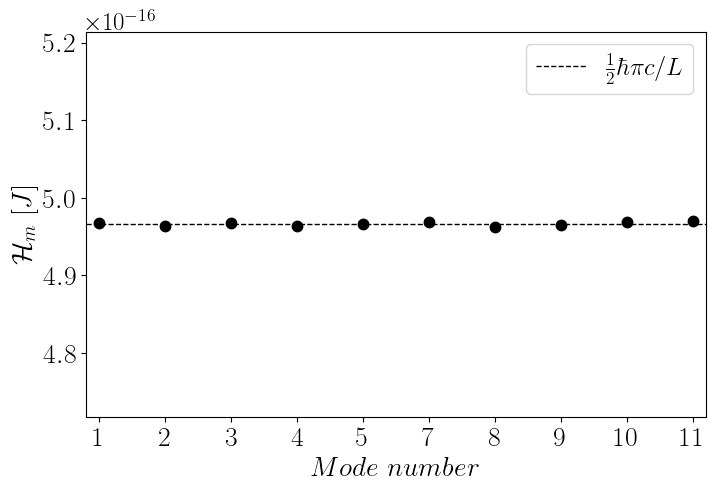

[1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1.]


In [15]:
with open('Mode_big_ppp300_groundstate_testreal.npy', 'rb') as f:
    C0 = np.load(f)
    C1 = np.load(f)
    x = np.load(f)
    FFF = np.load(f)
    Phi_L2 = np.load(f)
    u = np.load(f)
    t = np.load(f)
    E_quad = np.load(f)
    E_modal = np.load(f)
    E_modes_0 = np.load(f)
    o0_bands = np.load(f)
    pick = np.load(f)

    
hbar = 1.05457182e-34
LL = 0.1e-9
N = 10
mode_visu = [0,1,2,3,4,6,7,8,9,10] # modes you want

# ====================== Plots ======================

fonty = 17
fig, ax2 = plt.subplots(figsize=(8,4))
plt.rc('text', usetex=True)


# Twin axis for F(x)
ax1 = ax2.twinx()
ax2.tick_params(axis='x', labelsize=fonty)
ax2.tick_params(axis='y', labelsize=fonty)
ax2.plot(x, FFF, 'k--', linewidth=1,alpha=0.5)
ax2.axhline(y=0, color='k',linestyle='--',linewidth=1., alpha=0.5)      
ax2.set_ylabel(r"$F(x)$ $[s^2/m^2]$", fontsize=fonty)
#ax2.legend(loc="upper left")
    
# Store plotted lines to extract their colors
lines = []
#for n in range(N):
for n in mode_visu:
    line, = ax1.plot(x, Phi_L2[:, n],
                     label=fr"$\phi_{{{n+1}}}(x)$",
                     linewidth=2)
    lines.append(line)
    
    
ax1.tick_params(axis='x', labelsize=fonty)
ax1.tick_params(axis='y', labelsize=fonty)
ax2.set_xlabel(r'$x$ $[m]$', fontsize=fonty)
ax1.set_ylabel(r'$Mode$ $\tilde{\phi}_m(x)$ $[m^{-1/2}]$', fontsize=fonty)
#ax1.legend(loc="upper left",fontsize=fonty-4)
#ax1.legend(loc='lower center',
#    bbox_to_anchor=(0.5, 1.08),
#    ncol=5,fontsize=fonty-6)
ax2.set_xlim(-LL*0.05, LL+LL*0.05)

#ax = plt.gca()
ax2.xaxis.get_offset_text().set_fontsize(fonty-2)
ax1.yaxis.get_offset_text().set_fontsize(fonty-2)
ax2.yaxis.get_offset_text().set_fontsize(fonty-2)


# Add box boundaries
ax1.axvline(0, color="black", lw=3)
ax1.axvline(LL, color="black", lw=3)

#plt.title(f"First {N} modes and permittivity profile $F(x)$")
plt.tight_layout()
plt.show()

fig.savefig('Modesfinite_quantum_groundstate.png', format='png', dpi=1000, bbox_inches='tight')


omegana1 = np.pi*vv/LL
omegana2 = 2*np.pi*vv/LL
omegana3 = 3*np.pi*vv/LL
omegana4 = 4*np.pi*vv/LL


fonty = 22
fig4 = plt.figure(4, figsize=(6, 5))
plt.rc('text', usetex=True)

flat_array = np.concatenate(o0_bands)  # shape: (total_modes,)
print(flat_array)
for b, oo in enumerate(flat_array[mode_visu],start=0):
    if b < N-1:
        color = lines[b].get_color()  # match mode color
        plt.plot(b,oo,'.',markersize=25., alpha=1,color=color)
    else:
        color = lines[b].get_color()  # match mode color
        plt.plot(b,oo,'.',markersize=25., alpha=1,color=color)
        
plt.plot(b,oo,'.',markersize=25., alpha=1,color=color)
 
plt.plot(0,omegana1,'k*',markersize=13,label=r'$\omega_1=\pi c/L$')
plt.plot(1,omegana2,'k.',markersize=15)
plt.plot(2,omegana2,'k.',markersize=15,label=r'$\omega_2=2\pi c/L$')
plt.plot(3,omegana3,'kx',markersize=15)
plt.plot(4,omegana3,'kx',markersize=15)
plt.plot(5,omegana3,'kx',markersize=15,label=r'$\omega_3=3\pi c/L$')
plt.plot(6,omegana4,'ks',markersize=7)
plt.plot(7,omegana4,'ks',markersize=7)
plt.plot(8,omegana4,'ks',markersize=7)
plt.plot(9,omegana4,'ks',markersize=7,label=r'$\omega_4=4\pi c/L$')
#plt.plot(2,omegana1,'kx',markersize=8)
#plt.plot(3,omegana1,'kx',markersize=8)              
plt.legend(loc="lower right",fontsize=fonty)     

#plt.legend(loc="upper left",fontsize=fonty-2)    
plt.xlabel(r'$Mode$ $number$',fontsize=fonty)
plt.ylabel(r'$Frequency$ $[rad/s]$',fontsize=fonty)
plt.xticks(size=fonty)
plt.yticks(size=fonty)

# Set font size for the offset text
ax = plt.gca()
ax.xaxis.get_offset_text().set_fontsize(fonty)
ax.yaxis.get_offset_text().set_fontsize(fonty)

plt.xlim(-0.2, 9.2)   # set the ylim to ymin, ymax
#plt.xlim(0.,40)   # set the ylim to ymin, ymax
#plt.ylim(0., 2e17)   # set the ylim to ymin, ymax
#plt.grid()
plt.yscale('linear')
plt.xticks([0,1,2,3,4,5,6,7,8,9], [r'$1$',r'$2$',r'$3$',r'$4$',r'$5$',r'$7$',r'$8$',r'$9$',r'$10$',r'$11$'])
fig4 = plt.gcf()
plt.show()

fig4.savefig('Eigenvalue_problem_HQO_groundstate.png', format='png', dpi=1000, bbox_inches='tight')





fonty = 20
fig, ax2 = plt.subplots(figsize=(8,4))
plt.rc('text', usetex=True)


# Twin axis for F(x)
ax1 = ax2.twinx()
ax2.tick_params(axis='x', labelsize=fonty)
ax2.tick_params(axis='y', labelsize=fonty)
ax2.plot(x, FFF, 'k--', linewidth=1,alpha=0.5)
ax2.axhline(y=0, color='k',linestyle='--',linewidth=1., alpha=0.5)      
ax2.set_ylabel(r"$F(x)$ $[s^2/m^2]$", fontsize=fonty)
#ax2.legend(loc="upper left")
    
# Store plotted lines to extract their colors
snap_idx = np.linspace(0, Nt-1, 4, dtype=int)
for si in snap_idx:
    if si < 1:
        #ax1.plot(x, uL2[si],
        #        label=fr"$t={t[si]:.2e}$",
        #        linewidth=2)
        ax1.plot(x, u[si],
                label=fr"$t={t[si]:.2e}$",
                linewidth=2)
    else:
        #ax1.plot(x, uL2[si],
        #        label=fr"$t={t[si]:.2e}$",
        #        linewidth=2)
        ax1.plot(x, u[si],
                label=fr"$t={t[si]:.2e}$",
                linewidth=2,alpha=0.5)
    
ax1.tick_params(axis='x', labelsize=fonty)
ax1.tick_params(axis='y', labelsize=fonty)
ax2.set_xlabel(r'$x$ $[m]$', fontsize=fonty)
ax1.set_ylabel(r'$E(x,t)$ $[V/m]$', fontsize=fonty)
ax1.legend(loc="lower center",fontsize=fonty-6)
#ax1.legend(loc='upper center',
#    bbox_to_anchor=(0.5, 1.45),
#    ncol=2,fontsize=fonty-6)
ax2.set_xlim(-LL*0.05, LL+LL*0.05)


#ax = plt.gca()
ax2.xaxis.get_offset_text().set_fontsize(fonty-2)
ax1.yaxis.get_offset_text().set_fontsize(fonty-2)
ax2.yaxis.get_offset_text().set_fontsize(fonty-2)


# Add box boundaries
ax1.axvline(0, color="black", lw=3)
ax1.axvline(LL, color="black", lw=3)

#plt.title(f"First {N} modes and permittivity profile $F(x)$")
plt.tight_layout()
plt.show()

fig.savefig('Evol_disp_HQO_groundstate_inabox.png', format='png', dpi=1000, bbox_inches='tight')



print(E0,np.sum(E_modes_0[pick]))
# -- Plots
fonty = 20
fig5 = plt.figure(5, figsize=(8, 5))
plt.rc('text', usetex=True)

plt.plot(t, E_quad,           label=r'$Physical$')
plt.plot(t, E_modal, ':', label=r'$Modal$')

plt.xticks(size=fonty)
plt.yticks(size=fonty)
plt.xlabel(r'$Time$ $[s]$',fontsize=fonty)
plt.ylabel(r'$Total$ $energy$ $\mathcal{E}$ $[J]$',fontsize=fonty)
plt.legend(loc="lower left",fontsize=fonty-2); 
plt.tight_layout()
plt.xlim(0,t[-1])
plt.ylim(N*(0.5*hbar*np.pi*vv/LL)-0.05*(0.5*hbar*np.pi*vv/LL)*N,N*(0.5*hbar*np.pi*vv/LL)+0.05*(0.5*hbar*np.pi*vv/LL)*N)

# Set font size for the offset text
ax = plt.gca()
ax.xaxis.get_offset_text().set_fontsize(fonty-2)
ax.yaxis.get_offset_text().set_fontsize(fonty-2)

plt.show()



fonty = 20
fig4 = plt.figure(4, figsize=(8, 5))
plt.rc('text', usetex=True)

plt.axhline(y=(0.5*hbar*np.pi*vv/LL),color="black", lw=1.,linestyle='--',label=r'$\frac{1}{2}\hbar \pi c/L$')

for b, oo in enumerate(flat_array[mode_visu],start=0):
    print(b)
    if b < N:
        print(b)
        color = lines[b].get_color()  # match mode color
        plt.plot(b,E_modes_0[mode_visu[b]],'.',markersize=15., alpha=1,color='k')

        
plt.legend(loc="best",fontsize=fonty-2)    
plt.xlabel(r'$Mode$ $number$',fontsize=fonty)
plt.ylabel(r'$\mathcal{H}_m$ $[J]$',fontsize=fonty)
plt.xticks(size=fonty)
plt.yticks(size=fonty)

# Set font size for the offset text
ax = plt.gca()
ax.xaxis.get_offset_text().set_fontsize(fonty-2)
ax.yaxis.get_offset_text().set_fontsize(fonty-2)

plt.xlim(-0.2, 9.2)   # set the ylim to ymin, ymax
#plt.xlim(0.,40)   # set the ylim to ymin, ymax
plt.ylim((0.5*hbar*np.pi*vv/LL)-0.05*(0.5*hbar*np.pi*vv/LL),(0.5*hbar*np.pi*vv/LL)+0.05*(0.5*hbar*np.pi*vv/LL))
#plt.grid()
plt.yscale('linear')
plt.xticks([0,1,2,3,4,5,6,7,8,9], [r'$1$',r'$2$',r'$3$',r'$4$',r'$5$',r'$7$',r'$8$',r'$9$',r'$10$',r'$11$'])
fig4 = plt.gcf()
plt.show()

#fig4.savefig('Eigenvalue_problem_HQO_3.png', format='png', dpi=1000, bbox_inches='tight')



print(np.sqrt(np.trapz(Phi_L2**2, x, axis=0)))


### → Figure 9 — Excited state ($n_1 = 1$, $n_{i>1} = 0$)

Loads the precomputed excited-state mode profile
(`Mode_big_ppp300_excitedstate_10modes_QHO_testreal.npy`) and plots
the field and energy spectrum with one mode in its first excited state.
Produces `Modesfinite_quantum_excitedstate.png`
and `Eigenvalue_problem_HQO_excitedstate.png`.


In [ ]:
from matplotlib.ticker import ScalarFormatter


Lam = 0.025e-9
C0ana = 100
CC1_analytic = (2*np.sqrt(2) + np.sqrt(8 + C0ana))**2
print(C0ana,CC1_analytic)

C0 = -C0ana*eps0*mu0
C1 = CC1_analytic*eps0*mu0

C00 = C0
C01 = 3*(C00+C1)-C1
C02 = 5*(C00+C1)-C1

# ---- sub‑medium definitions  (same numbers you used) -----------------
medium_A = (C02, C1, Lam, 1)   # eps0, eps1, lam, m
medium_B = (C01, C1, Lam/2, 2)
medium_C = (C00, C1, Lam/3, 3)   # eps0, eps1, lam, m
medium_D = (C01, C1, Lam/4, 4)

x, FFF, o0_bands, Phi_bands = slab_concat_big(
        params_A = medium_A,
        params_B = medium_B,
        params_C = medium_C,
        params_D = medium_D,
        ppp      = 300,
        n_bands  = 3)

print("First omeg0:", np.concatenate(o0_bands))


# ---------- You already have ε-normalized eigenmodes ----------
Phi_eps = np.hstack(Phi_bands)          # (Nx, K)  columns are eigenmodes
omega   = np.concatenate(o0_bands)      # (K,)
Nx, K   = Phi_eps.shape

# ---------- Make an L2-rescaled copy (per column only) ----------
# Use simple trapz for L2; (optionally) trapezoid weights W if you prefer.
l2 = np.sqrt(np.trapz(Phi_eps**2, x, axis=0))   # shape (K,)
Phi_L2 = Phi_eps / l2                           # still exact eigenvectors


# (Sanity) M-orthogonality off-diagonals stay ~0; diagonals are not ±1 anymore
Mmat    = np.diag(FFF[1:-1])
Phi_int = Phi_L2[1:-1, :]
S = Phi_int.T @ (Mmat @ Phi_int)                # Φᵀ M Φ   (K,K)
# Build T on interior exactly as in your solver
dx   = x[1] - x[0]
Nint = Phi_int.shape[0]
main =  2.0*np.ones(Nint)/dx**2
off  = -1.0*np.ones(Nint-1)/dx**2
Tmat = np.diag(main) + np.diag(off,1) + np.diag(off,-1)
Kmat = Phi_int.T @ (Tmat  @ Phi_int)            # Φᵀ T Φ   (K,K)

# (Optional) verify eigen relation still holds (it does; scaling doesn’t change it)
res = Tmat @ Phi_int - Mmat @ (Phi_int * (omega**2))
rel_inf = np.linalg.norm(res, np.inf) / (np.linalg.norm(Tmat @ Phi_int, np.inf) + 1e-300)
print("eig residual (rel inf) after L2 rescale =", f"{rel_inf:.3e}")

# ---------- Choose initial modal amplitudes using L2 interpretation ----------
# --- Choose initial modal amplitudes q(0)
u0 = 1*(Phi_eps[:,0]+Phi_eps[:,1]+Phi_eps[:,2]+Phi_eps[:,3]+Phi_eps[:,4]+Phi_eps[:,6]+Phi_eps[:,7]+Phi_eps[:,8]+Phi_eps[:,9]+Phi_eps[:,10])     
q_eps = np.trapz(FFF[:, None] * u0[:, None] * Phi_eps, x, axis=0)
print(q_eps)
qL2 = q_eps * l2                               # D^{-1} q_eps
print(qL2)

# Field consistency check
u_from_eps = Phi_eps @ q_eps
u_from_L2  = Phi_L2  @ (l2 * q_eps)    # must match u_from_eps
print("||u_eps - u_L2|| / ||u_eps|| =",
      np.linalg.norm(u_from_eps - u_from_L2) / (np.linalg.norm(u_from_eps) + 1e-300))


# Example: equal-energy-by-displacement: q_n(0) = 1 (you can choose any rule)
Etilde0 = 2.
Etilde0 = (2*np.pi*vv*mu0*hbar/(1e-10*AA*(C0+C1)))**0.5
q0  = np.zeros(K)
#pick = [0,1,2,3,4,5,6,7,8,9,10,11,12,13,14,15,16,17,18,19,20,21,22,23,24,25,26] # modes you want
pick = [4,11,12,15,17,18,23,24,25,26] # modes you want
#q0[pick] = 1.0 / omega[pick]
q0[pick] = Etilde0
print(q0)
dq0 = np.zeros_like(q0)

# ---------- Reconstruct fields and compute energy (normalization-agnostic) ----------
# Time evolution (decoupled cosines) is valid since columns are still eigenvectors
Tfinal = 2*np.pi/np.max(omega)
Nt = 1000
t  = np.linspace(0.0, Tfinal, Nt)
q  = q0 * np.cos(np.outer(t, omega))            # (Nt,K)
dq = -q0 * omega * np.sin(np.outer(t, omega))   # (Nt,K)
qL2  = qL2 * np.cos(np.outer(t, omega))            # (Nt,K)
dqL2 = -qL2 * omega * np.sin(np.outer(t, omega))   # (Nt,K)
        
# --- derivatives of Phi (spatial) on the same grid x
# use central differences (np.gradient handles boundaries)
Phi_x = np.gradient(Phi_L2, x, axis=0)   # shape (Nx, K)
# Note: Phi_x[i,n] ≈ ∂x phi_n(x_i)

# --- time integral of modal q: Qint(t) = ∫_0^t q(s) ds
# use cumulative trapezoid in time
# q is (Nt, K); cumtrapz returns (Nt-1, K) unless initial=0
q_int = cumulative_trapezoid(q, t, axis=0, initial=0.0)   # shape (Nt, K)
# q_int[it] is ∫_0^{t[it]} q(s) ds

# reconstruct E(x,t) in physical space
# E(t,x) = q(t) @ Phi_eps.T  -> shape (Nt, Nx)
E_space = q @ Phi_L2.T    # (Nt, Nx)

# reconstruct B from modal integral:
# B(t,x) = B0(x) + Phi_x @ q_int(t)  => doing as row products:
B_from_modal = q_int @ Phi_x.T    # (Nt, Nx)  (this is the integral-part)
# We impose B(0,x)=B0=0 because dq0 = 0 so
E_quad = 0.5*(AA/mu0)*( np.trapz(FFF[None,:]*E_space**2, x, axis=1)
                   + np.trapz(B_from_modal**2, x, axis=1) )

E_phys0 = E_quad[0]
E_phys_minmax = np.max(E_quad) - np.min(E_quad)
rel_drift = E_phys_minmax / (np.mean(E_quad) + 1e-300)

print("E_phys(0) =", E_phys0)
print("energy absolute drift (max-min) =", E_phys_minmax)
print("energy relative drift (max-min)/mean =", rel_drift)

# if you used B0 = 0, compare to electric-only at t=0
E_elec_at0 = 0.5 * (AA/mu0)* np.trapz(FFF * E_space[0,:]**2, x)
print("0.5*∫eps E^2 at t=0 =", E_elec_at0)
print("abs diff Ephys(0) - E_elec_at0 =", np.abs(E_phys0 - E_elec_at0))
print("relative diff:", np.abs(E_phys0 - E_elec_at0)/(np.abs(E_phys0)+1e-300))   
        
# ---------------------------
# ELECTRIC PART (per mode)
# E_elec = 0.5 * ∫ ε E^2 dx = 0.5 * q.T S q  where S_ij = ∫ ε φ_i φ_j dx
# per-mode attribution: elec_per_mode[n] = 0.5 * q_n * (S q)_n
# ---------------------------
# build S using trapz (consistent with q)
# compute S @ q[t] quickly by precomputing S (KxK)
S2 = np.zeros((K, K))
for i in range(K):
    for j in range(i, K):
        Sij = np.trapz(FFF * Phi_L2[:, i] * Phi_L2[:, j], x)
        S2[i, j] = Sij
        S2[j, i] = Sij

# compute S q for all times: (Nt, K) = q @ S.T
Sq = q @ S2.T   # (Nt, K)

# electric energy per mode time series (Nt, K)
E_elec_per_mode = 0.5 * (AA/mu0)* (q * Sq)    # elementwise: 0.5 * q_n * (S q)_n

# ---------------------------
# MAGNETIC PART (per mode)
# B(t) = B0 + Phi_x @ q_int(t)
# E_mag = 0.5 * ∫ B^2 dx
# expand: E_mag = 0.5*∫B0^2 dx  + ∫ B0 (Phi_x q_int) dx + 0.5 * q_int^T R q_int
# where cB0_n = ∫ B0 * phi_x_n dx  (vector), and R_{nm} = ∫ phi_x_n * phi_x_m dx
# We attribute per-mode contributions:
#   mag_const = 0.5*∫B0^2 dx (scalar)
#   mag_cross_per_mode[n] = 0.5 * 2 * cB0_n * q_int_n  = cB0_n * q_int_n
#   mag_quad_per_mode[n] = 0.5 * q_int_n * (R q_int)_n
# Sum over n gives full magnetic energy minus the constant (mag_const).
# ---------------------------

# compute cB0 (K,) = ∫ B0(x) * phi_x_n(x) dx
if 'B0' not in globals():
    B0 = np.zeros(Nx)

cB0 = np.zeros(K)
for n in range(K):
    cB0[n] = np.trapz(B0 * Phi_x[:, n], x)

# compute R matrix (KxK) = ∫ phi_x_n * phi_x_m dx
R = np.zeros((K, K))
for i in range(K):
    for j in range(i, K):
        Rij = np.trapz(Phi_x[:, i] * Phi_x[:, j], x)
        R[i, j] = Rij
        R[j, i] = Rij

# compute R @ q_int for all times: (Nt, K)
R_qint = q_int @ R.T   # (Nt, K)

# magnetic per-mode contributions (Nt, K)
# cross term (assigned per-mode)
mag_cross_per_mode = (cB0[None, :] * q_int)   # (Nt, K)  <- equals 0.5*2*cB0*q_int
# quadratic part per mode
mag_quad_per_mode = 0.5 * (AA/mu0)* (q_int * R_qint)    # (Nt, K)

# total magnetic per mode (Nt, K)
E_mag_per_mode = mag_cross_per_mode + mag_quad_per_mode   # does NOT include mag_const

# ---------------------------
# TOTAL per-mode energy and checks
# ---------------------------
E_per_mode = E_elec_per_mode + E_mag_per_mode    # (Nt, K)
E_modal = np.sum(E_per_mode,axis=1)
E_modes_0 = E_per_mode[0,:]


with open('Mode_big_ppp300_excitedstate_10modes_QHO_testreal.npy', 'wb') as f:
    np.save(f,C00)
    np.save(f,C01)
    np.save(f,C02)
    np.save(f,C1)
    np.save(f, x)
    np.save(f, FFF)
    np.save(f, Phi_L2)
    np.save(f, E_space)
    np.save(f, t)
    np.save(f, E_quad)
    np.save(f, E_modal)
    np.save(f, E_modes_0)
    np.save(f, o0_bands)
    np.save(f, pick)
    

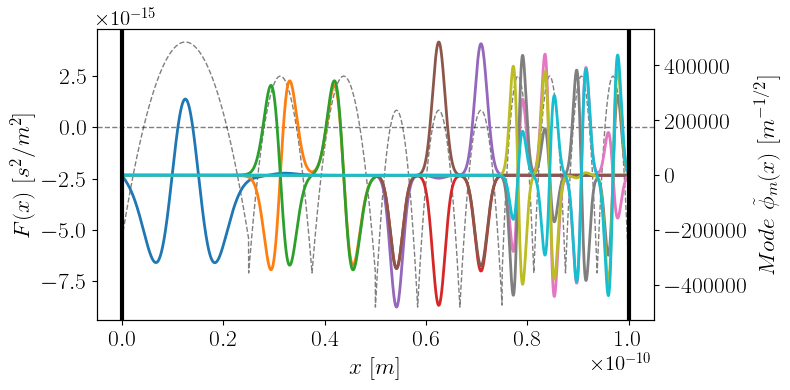

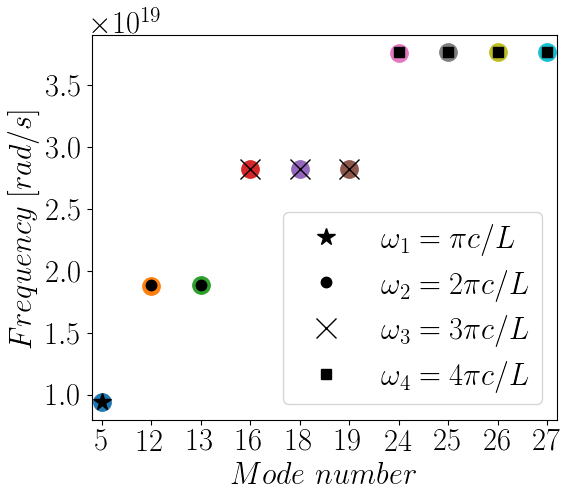

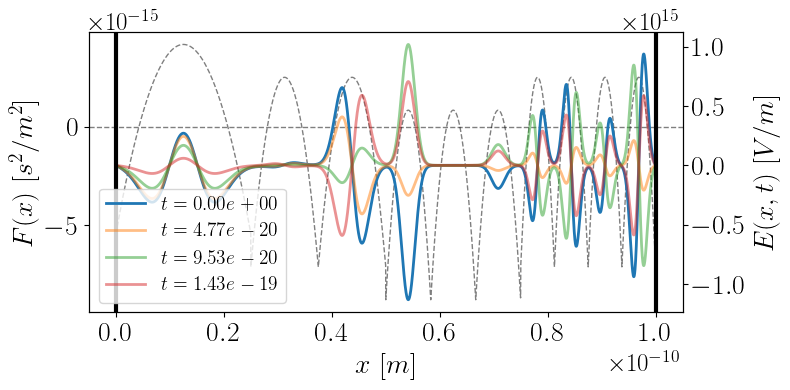

2.1363221437247485e-07 1.293860916409839e-14


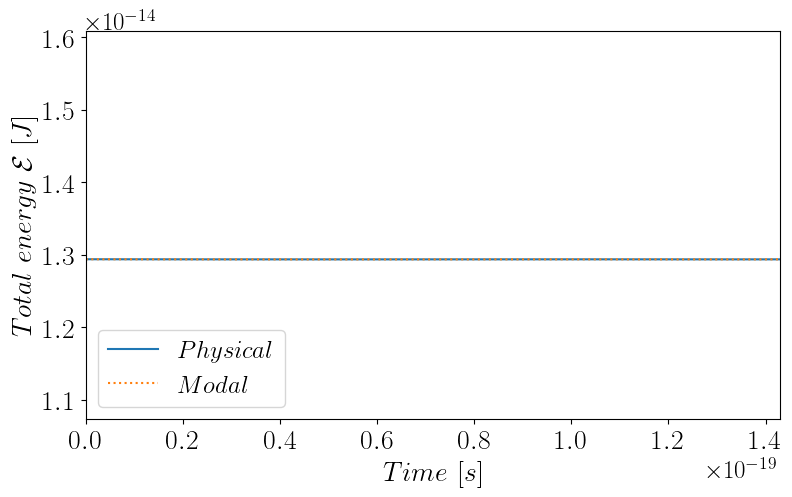

0
1
2
3
4
5
6
7
8
9


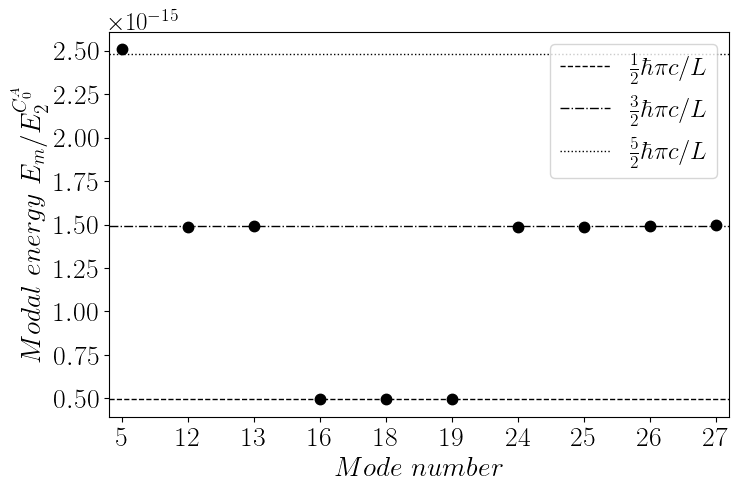

[1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1.
 1. 1. 1. 1. 1. 1.]


In [17]:
#with open('Mode_big_ppp300_excitedstate_total_27modes.npy', 'rb') as f:
with open('Mode_big_ppp300_excitedstate_10modes_QHO_testreal.npy', 'rb') as f:
    C00 = np.load(f)
    C01 = np.load(f)
    C02 = np.load(f)
    C1 = np.load(f)
    x = np.load(f)
    FFF = np.load(f)
    Phi_L2 = np.load(f)
    u = np.load(f)
    t = np.load(f)
    E_quad = np.load(f) 
    E_modal = np.load(f)
    E_modes_0 = np.load(f)
    o0_bands = np.load(f)
    pick = np.load(f)


LL = 1e-10
N =27
mode_visu = pick

# ====================== Plots ======================

fonty = 17
fig, ax2 = plt.subplots(figsize=(8,4))
plt.rc('text', usetex=True)


# Twin axis for F(x)
ax1 = ax2.twinx()
ax2.tick_params(axis='x', labelsize=fonty)
ax2.tick_params(axis='y', labelsize=fonty)
ax2.plot(x, FFF, 'k--', linewidth=1,alpha=0.5)
ax2.axhline(y=0, color='k',linestyle='--',linewidth=1., alpha=0.5)      
ax2.set_ylabel(r"$F(x)$ $[s^2/m^2]$", fontsize=fonty)
#ax2.legend(loc="upper left")
    
# Store plotted lines to extract their colors
lines = []
#for n in range(N):
for n in mode_visu:
    line, = ax1.plot(x, Phi_L2[:, n],
                     label=fr"$\phi_{{{n+1}}}(x)$",
                     linewidth=2)
    lines.append(line)
    
    
ax1.tick_params(axis='x', labelsize=fonty)
ax1.tick_params(axis='y', labelsize=fonty)
ax2.set_xlabel(r'$x$ $[m]$', fontsize=fonty)
ax1.set_ylabel(r'$Mode$ $\tilde{\phi}_m(x)$ $[m^{-1/2}]$', fontsize=fonty)
#ax1.legend(loc="upper left",fontsize=fonty-4)
#ax1.legend(loc='lower center',
#bbox_to_anchor=(0.5, 1.08),
#    ncol=5,fontsize=fonty-6)
ax2.set_xlim(-LL*0.05, LL+LL*0.05)


#ax = plt.gca()
ax2.xaxis.get_offset_text().set_fontsize(fonty-2)
ax1.yaxis.get_offset_text().set_fontsize(fonty-2)
ax2.yaxis.get_offset_text().set_fontsize(fonty-2)


# Add box boundaries
ax1.axvline(0, color="black", lw=3)
ax1.axvline(LL, color="black", lw=3)

#plt.title(f"First {N} modes and permittivity profile $F(x)$")
plt.tight_layout()
plt.show()

fig.savefig('Modesfinite_quantum_excitedstate.png', format='png', dpi=1000, bbox_inches='tight')







omegana1 = np.pi*vv/LL
omegana2 = 2*np.pi*vv/LL
omegana3 = 3*np.pi*vv/LL
omegana4 = 4*np.pi*vv/LL

fonty = 22
fig4 = plt.figure(4, figsize=(6, 5))
plt.rc('text', usetex=True)

flat_array = np.concatenate(o0_bands)  # shape: (total_modes,)
for b, oo in enumerate(flat_array[mode_visu],start=0):
    if b < N-1:
        color = lines[b].get_color()  # match mode color
        plt.plot(b,oo,'.',markersize=25., alpha=1,color=color)
    else:
        color = lines[b].get_color()  # match mode color
        plt.plot(b,oo,'.',markersize=25., alpha=1,color=color)
        

plt.plot(0,omegana1,'k*',markersize=13,label=r'$\omega_1=\pi c/L$')
plt.plot(1,omegana2,'k.',markersize=15)
plt.plot(2,omegana2,'k.',markersize=15,label=r'$\omega_2=2\pi c/L$')
plt.plot(3,omegana3,'kx',markersize=15)
plt.plot(4,omegana3,'kx',markersize=15)
plt.plot(5,omegana3,'kx',markersize=15,label=r'$\omega_3=3\pi c/L$')
plt.plot(6,omegana4,'ks',markersize=7)
plt.plot(7,omegana4,'ks',markersize=7)
plt.plot(8,omegana4,'ks',markersize=7)
plt.plot(9,omegana4,'ks',markersize=7,label=r'$\omega_4=4\pi c/L$')
#plt.plot(2,omegana1,'kx',markersize=8)
#plt.plot(3,omegana1,'kx',markersize=8)              
plt.legend(loc="lower right",fontsize=fonty) 
        
#plt.legend(loc="upper left",fontsize=fonty-2)    
plt.xlabel(r'$Mode$ $number$',fontsize=fonty)
plt.ylabel(r'$Frequency$ $[rad/s]$',fontsize=fonty)
plt.xticks(size=fonty)
plt.yticks(size=fonty)

# Set font size for the offset text
ax = plt.gca()
ax.xaxis.get_offset_text().set_fontsize(fonty)
ax.yaxis.get_offset_text().set_fontsize(fonty)

plt.xlim(-0.2, 9.2)   # set the ylim to ymin, ymax
#plt.xlim(0.,40)   # set the ylim to ymin, ymax
#plt.ylim(0., 2e17)   # set the ylim to ymin, ymax
#plt.grid()
plt.yscale('linear')
plt.xticks([0,1,2,3,4,5,6,7,8,9], [r'$5$',r'$12$',r'$13$',r'$16$',r'$18$',r'$19$',r'$24$',r'$25$',r'$26$',r'$27$'])
fig4 = plt.gcf()
plt.show()

fig4.savefig('Eigenvalue_problem_HQO_excitedstate.png', format='png', dpi=1000, bbox_inches='tight')





fonty = 20
fig, ax2 = plt.subplots(figsize=(8,4))
plt.rc('text', usetex=True)


# Twin axis for F(x)
ax1 = ax2.twinx()
ax2.tick_params(axis='x', labelsize=fonty)
ax2.tick_params(axis='y', labelsize=fonty)
ax2.plot(x, FFF, 'k--', linewidth=1,alpha=0.5)
ax2.axhline(y=0, color='k',linestyle='--',linewidth=1., alpha=0.5)      
ax2.set_ylabel(r"$F(x)$ $[s^2/m^2]$", fontsize=fonty)
#ax2.legend(loc="upper left")
    
# Store plotted lines to extract their colors
snap_idx = np.linspace(0, Nt-1, 4, dtype=int)
for si in snap_idx:
    if si < 1:
        #ax1.plot(x, uL2[si],
        #        label=fr"$t={t[si]:.2e}$",
        #        linewidth=2)
        ax1.plot(x, u[si],
                label=fr"$t={t[si]:.2e}$",
                linewidth=2)
    else:
        #ax1.plot(x, uL2[si],
        #        label=fr"$t={t[si]:.2e}$",
        #        linewidth=2)
        ax1.plot(x, u[si],
                label=fr"$t={t[si]:.2e}$",
                linewidth=2,alpha=0.5)
    
ax1.tick_params(axis='x', labelsize=fonty)
ax1.tick_params(axis='y', labelsize=fonty)
ax2.set_xlabel(r'$x$ $[m]$', fontsize=fonty)
ax1.set_ylabel(r'$E(x,t)$ $[V/m]$', fontsize=fonty)
ax1.legend(loc="lower left",fontsize=fonty-6)
#ax1.legend(loc='upper center',
#    bbox_to_anchor=(0.52, 1.45),
#    ncol=2,fontsize=fonty-6)
ax2.set_xlim(-LL*0.05, LL+LL*0.05)


#ax = plt.gca()
ax2.xaxis.get_offset_text().set_fontsize(fonty-2)
ax1.yaxis.get_offset_text().set_fontsize(fonty-2)
ax2.yaxis.get_offset_text().set_fontsize(fonty-2)


# Add box boundaries
ax1.axvline(0, color="black", lw=3)
ax1.axvline(LL, color="black", lw=3)

#plt.title(f"First {N} modes and permittivity profile $F(x)$")
plt.tight_layout()
plt.show()

fig.savefig('Evol_disp_HQO_excitedstate_inabox.png', format='png', dpi=1000, bbox_inches='tight')



print(E0,np.sum(E_modes_0[pick]))
# -- Plots
fonty = 20
fig5 = plt.figure(5, figsize=(8, 5))
plt.rc('text', usetex=True)

plt.plot(t, E_quad,           label=r'$Physical$')
plt.plot(t, E_modal, ':', label=r'$Modal$')

plt.xticks(size=fonty)
plt.yticks(size=fonty)
plt.xlabel(r'$Time$ $[s]$',fontsize=fonty)
plt.ylabel(r'$Total$ $energy$ $\mathcal{E}$ $[J]$',fontsize=fonty)
plt.legend(loc="lower left",fontsize=fonty-2); 
plt.tight_layout()
plt.xlim(0,t[-1])
plt.ylim(N*(0.5*hbar*np.pi*vv/LL)-0.2*(0.5*hbar*np.pi*vv/LL)*N,N*(0.5*hbar*np.pi*vv/LL)+0.2*(0.5*hbar*np.pi*vv/LL)*N)


# Set font size for the offset text
ax = plt.gca()
ax.xaxis.get_offset_text().set_fontsize(fonty-2)
ax.yaxis.get_offset_text().set_fontsize(fonty-2)

plt.show()



fonty = 20
fig4 = plt.figure(4, figsize=(8, 5))
plt.rc('text', usetex=True)

plt.axhline(y=(0.5*hbar*np.pi*vv/LL),color="black", lw=1.,linestyle='--',label=r'$\frac{1}{2}\hbar \pi c/L$')
plt.axhline(y=(1.5*hbar*np.pi*vv/LL),color="black", lw=1.,linestyle='-.',label=r'$\frac{3}{2}\hbar \pi c/L$')
plt.axhline(y=(2.5*hbar*np.pi*vv/LL),color="black", lw=1.,linestyle=':',label=r'$\frac{5}{2}\hbar \pi c/L$')

#plt.axhline(y=1,color="black", lw=1.,linestyle='--',label=r'$C_0^0+C_1$')
#plt.axhline(y=3,color="black", lw=1.,linestyle='-.',label=r'$C_0^1+C_1$')
#plt.axhline(y=5,color="black", lw=1.,linestyle=':',label=r'$C_0^2+C_1$')


for b, oo in enumerate(flat_array[mode_visu],start=0):
    if b < N:
        print(b)
        color = lines[b].get_color()  # match mode color
        plt.plot(b,E_modes_0[mode_visu[b]],'.',markersize=15., alpha=1,color='k')

        
plt.legend(loc="best",fontsize=fonty-2)    
plt.xlabel(r'$Mode$ $number$',fontsize=fonty)
plt.ylabel(r'$Modal$ $energy$ $E_m/E_2^{C_0^A}$',fontsize=fonty)
plt.xticks(size=fonty)
plt.yticks(size=fonty)

# Set font size for the offset text
ax = plt.gca()
ax.xaxis.get_offset_text().set_fontsize(fonty-2)
ax.yaxis.get_offset_text().set_fontsize(fonty-2)

plt.xlim(-0.2, 9.2)   # set the ylim to ymin, ymax
plt.xticks([0,1,2,3,4,5,6,7,8,9], [r'$5$',r'$12$',r'$13$',r'$16$',r'$18$',r'$19$',r'$24$',r'$25$',r'$26$',r'$27$'])
#plt.xlim(0.,40)   # set the ylim to ymin, ymax
#plt.ylim(0.8, 2)   # set the ylim to ymin, ymax
#plt.grid()
plt.yscale('linear')
fig4 = plt.gcf()
plt.show()

#fig4.savefig('Eigenvalue_problem_HQO_3.png', format='png', dpi=1000, bbox_inches='tight')



print(np.sqrt(np.trapz(Phi_L2**2, x, axis=0)))



### → Figure 7 — Classical electromagnetic energy spectrum

Overlays the Floquet-based energy decomposition on the QHO ladder
$\mathcal{H}_n = (n+\tfrac{1}{2})\hbar\omega_n$, closing the photon-energy analogy.
Produces `quantum_energy_box_Floquet.png`.


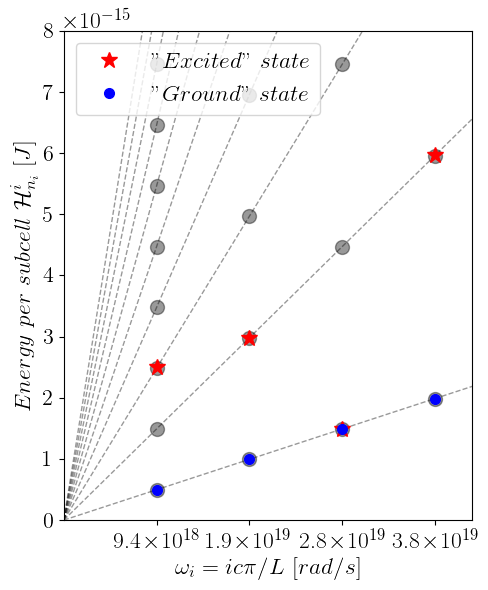

In [18]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.ticker import ScalarFormatter, FuncFormatter

with open('Mode_big_ppp300_groundstate_testreal.npy', 'rb') as f:
    C0 = np.load(f)
    C1 = np.load(f)
    x = np.load(f)
    FFF = np.load(f)
    Phi_L2 = np.load(f)
    u = np.load(f)
    t = np.load(f)
    E_quad = np.load(f)
    E_modal = np.load(f)
    E_modes_0_ground = np.load(f)
    o0_bands_ground = np.load(f)
    pick = np.load(f)

    
with open('Mode_big_ppp300_excitedstate_10modes_QHO_testreal.npy', 'rb') as f:
    C00 = np.load(f)
    C01 = np.load(f)
    C02 = np.load(f)
    C1 = np.load(f)
    x = np.load(f)
    FFF = np.load(f)
    Phi_L2 = np.load(f)
    u = np.load(f)
    t = np.load(f)
    E_quad = np.load(f) 
    E_modal = np.load(f)
    E_modes_0_excited = np.load(f)
    o0_bands_excited = np.load(f)
    pick = np.load(f)    


# Parameters
marki = 12
m_vals = np.arange(1, 6)   # discrete frequencies (mode indices)
n_vals = np.arange(0, 10)  # quantum numbers n

hbar = 1.05457182e-34
L = 1e-10
c = vv
omega_m = m_vals * np.pi * c / L   # actual discrete frequencies

fonty = 17
fig2 = plt.figure(2, figsize=(5,6))
plt.rc('text', usetex=True)

#plt.axvline(x=omega_m[0], color='tab:blue', linestyle='-', linewidth=1.)
#plt.axvline(x=omega_m[1], color='tab:orange', linestyle='-', linewidth=1.)
#plt.axvline(x=omega_m[2], color='tab:green', linestyle='-', linewidth=1.)

# Plot discrete black dots: E = (n+1/2)ħω_m
for n in n_vals:
    E = (n + 0.5) * hbar * omega_m
    plt.plot(omega_m, E, 'ko', markersize=10, alpha=0.4)

# Plot dashed lines: E = n ħ ω (continuous ω)
omega_cont = np.linspace(0, omega_m[-1]*1.1, 400)
for n in n_vals:
    E_line = (n + 0.5) * hbar * omega_cont
    plt.plot(omega_cont, E_line, 'k--', lw=1, alpha=0.4)

    
    
flat_array_excited = np.concatenate(o0_bands_excited)   # frequencies (len K)

plt.plot(flat_array_excited[[4]], E_modes_0_excited[4],'*', markersize=marki, alpha=1, color='r',label='$"Excited"$ $state$')
plt.plot(flat_array_excited[[11]], E_modes_0_excited[11]+E_modes_0_excited[12],'*', markersize=marki, alpha=1, color='r')
plt.plot(flat_array_excited[[15]], E_modes_0_excited[15]+E_modes_0_excited[17]+E_modes_0_excited[18],'*', markersize=marki, alpha=1, color='r')
plt.plot(flat_array_excited[[23]], E_modes_0_excited[23]+E_modes_0_excited[24]+E_modes_0_excited[25]+E_modes_0_excited[26],'*', markersize=marki, alpha=1, color='r')
      


flat_array_ground = np.concatenate(o0_bands_ground)   # frequencies (len K)

plt.plot(flat_array_ground[[0]], E_modes_0_ground[0],'.', markersize=marki+2, alpha=1, color='b',label='$"Ground"$ $state$')
plt.plot(flat_array_ground[[1]], E_modes_0_ground[1]+E_modes_0_ground[2],'.', markersize=marki+2, alpha=1, color='b')
plt.plot(flat_array_ground[[3]], E_modes_0_ground[3]+E_modes_0_ground[4]+E_modes_0_ground[6],'.', markersize=marki+2, alpha=1, color='b')
plt.plot(flat_array_ground[[7]], E_modes_0_ground[7]+E_modes_0_ground[8]+E_modes_0_ground[9]+E_modes_0_ground[10],'.', markersize=marki+2, alpha=1, color='b')
                  
    
    
plt.yticks(size=fonty)

ax = plt.gca()
ax.yaxis.set_major_formatter(ScalarFormatter(useMathText=True))
ax.ticklabel_format(axis='y', style='sci', scilimits=(0,0))
ax.yaxis.get_offset_text().set_fontsize(fonty)

# ---- Custom formatter for ω_m ticks ----
def sci_notation(val, pos):
    s = f"{val:.1e}"
    base, exp = s.split("e")
    return rf"$\textnormal{{{base}}} \! \times \! 10^{{{int(exp)}}}$"

# place ticks exactly at omega_m
ax.set_xticks(omega_m)
ax.xaxis.set_major_formatter(FuncFormatter(sci_notation))

plt.legend(loc='upper left',fontsize=fonty)
plt.xticks(fontsize=fonty)
plt.yticks(fontsize=fonty-1)

# ---- Axis labels ----
plt.xlabel(r'$\omega_i = ic\pi/L$ $[rad/s]$', fontsize=fonty)
plt.ylabel(r'$Energy$ $per$ $subcell$ $\mathcal{H}^i_{n_i}$ $[J]$', fontsize=fonty)

plt.xlim(0, omega_m[3]*1.1)
plt.ylim(0, 8e-15)
plt.tight_layout()

fig2 = plt.gcf()
plt.show()

fig2.savefig('quantum_energy_box_Floquet.png', format='png', dpi=1000, bbox_inches='tight')


## By Arnaud Lazarus - 06/13/2026